<a href="https://colab.research.google.com/github/brillante0302-eng/-/blob/main/%EA%B8%80%EB%A1%9C%EB%B2%8C_%EB%AF%B8%EB%94%94%EC%96%B4_%EC%9D%B4%EC%8A%88%EA%B0%80_%EB%B9%84%EB%A7%8C%EC%B9%98%EB%A3%8C%EC%A0%9C_%EC%88%98%EC%9A%94_%ED%99%95%EC%82%B0%EC%97%90_%EB%AF%B8%EC%B9%98%EB%8A%94_%EC%98%81%ED%96%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <글로벌 미디어 이슈가 비만치료제 수요 확산에 미치는 영향: Wegovy를 중심으로>

# 1단계: 문제 정의 및 도입 (Introduction & Overview)




*   어떤 글로벌 이슈가 Wegovy 매출에 영향을 미치는가?
*   어떤 국가에서 가장 빠르게 반응하는가?
*   다음 Wegovy 수요 급증을 예측할 수 있는가?




# 2단계: 데이터 수집 및 전처리 (Data Collection & Preprocessing)



*   목표: 결과값(매출/처방)과 원인값(미디어 이슈/검색량)을 시계열 데이터로 결합
*   데이터 구성:


*  * 결과 데이터(Y): Wegovy 분기별 매출 데이터 및 국가별 매출 데이터
* * 선행/독립 데이터(X):
     1. pytrends / 데이터: 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound' 등의 키워드 검색량 (국가별, 주별/월별)

     2. 뉴스 텍스트 마이닝: 주요 언론사의 위고비 관련 뉴스 기사 크롤링 및 감성 분석 / 키워드 빈도 추출

     3. 이벤트 더미 변수(X): FDA 승인일, 일론 머스크 등 유명인 언급 시점, 공급 부족 기사 발생 시점 등을 0과 1(또는 강도)로 표기한 이벤트 로그

# 2-1: 결과 데이터(Y): Wegovy 분기별 매출 데이터 및 국가별 매출 데이터



> Wegovy VS Ozempic



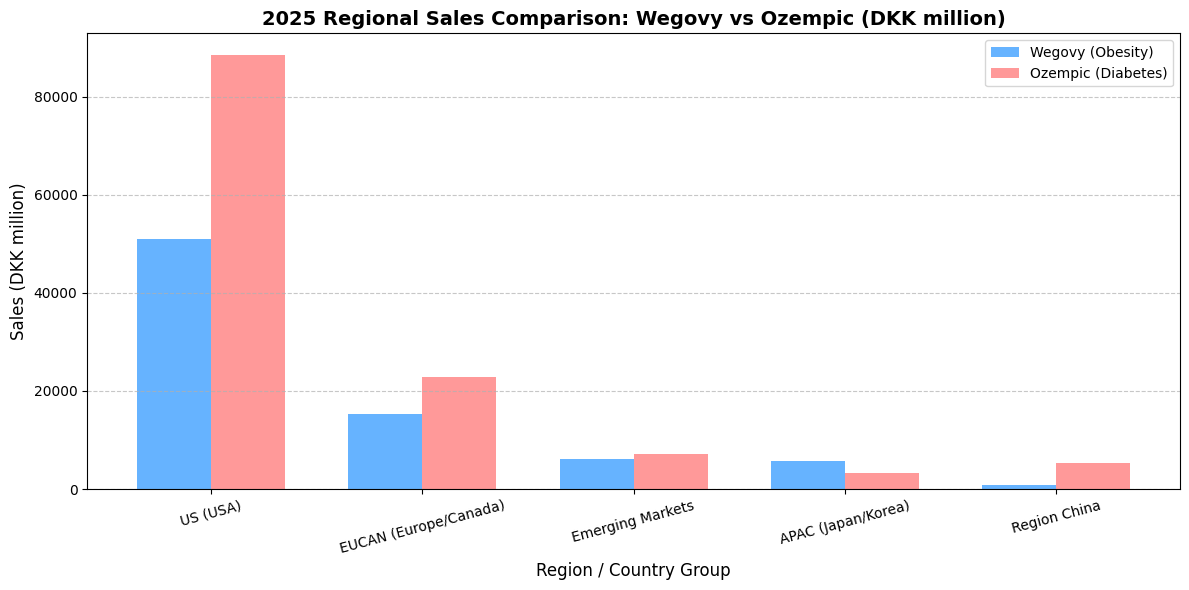

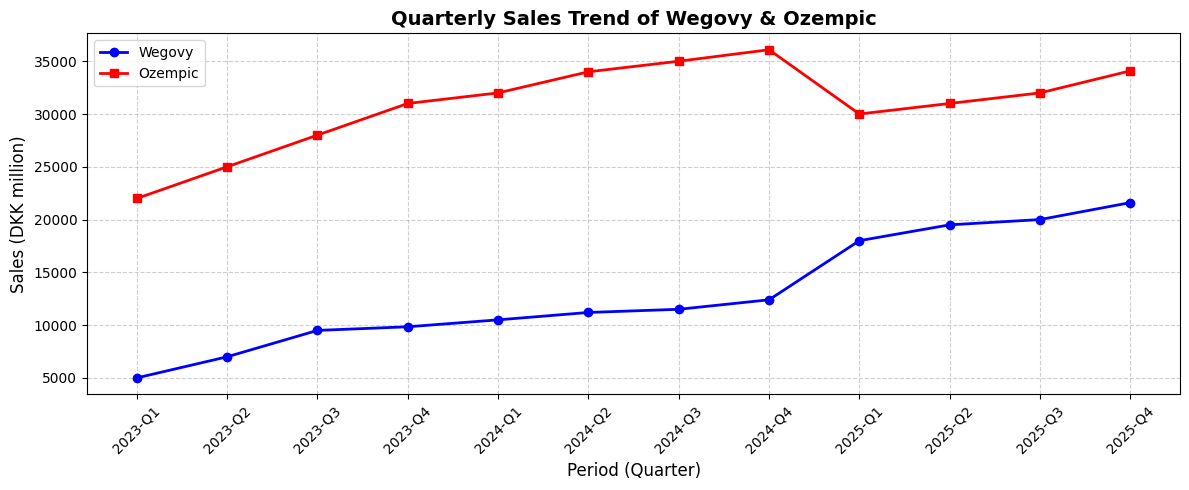

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 2025년 국가/지역별 매출 데이터프레이션 생성 (단위: DKK million)
regional_data = {
    'Region': ['US (USA)', 'EUCAN (Europe/Canada)', 'Emerging Markets', 'APAC (Japan/Korea)', 'Region China'],
    'Wegovy': [51015, 15383, 6100, 5812, 796],
    'Ozempic': [88467, 22774, 7235, 3214, 5399]
}
df_reg = pd.DataFrame(regional_data)

# 2. 분기별 추정 매출 데이터프레임 생성 (프로젝트 시계열 분석용)
quarterly_data = {
    'Period': ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4',
               '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4',
               '2025-Q1', '2025-Q2', '2025-Q3', '2025-Q4'],
    'Wegovy_Quarterly': [5000, 7000, 9500, 9843, 10500, 11200, 11500, 12400, 18000, 19500, 20000, 21606],
    'Ozempic_Quarterly': [22000, 25000, 28000, 31000, 32000, 34000, 35000, 36089, 30000, 31000, 32000, 34089]
}
df_qtr = pd.DataFrame(quarterly_data)

# --- 시각화 1: 국가/지역별 두 제품 매출 비교 (어느 국가에서 가장 큰 반응을 보이는가?) ---
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.35
x = range(len(df_reg['Region']))

ax.bar([i - bar_width/2 for i in x], df_reg['Wegovy'], bar_width, label='Wegovy (Obesity)', color='#66b3ff')
ax.bar([i + bar_width/2 for i in x], df_reg['Ozempic'], bar_width, label='Ozempic (Diabetes)', color='#ff9999')

ax.set_title('2025 Regional Sales Comparison: Wegovy vs Ozempic (DKK million)', fontsize=14, fontweight='bold')
ax.set_xlabel('Region / Country Group', fontsize=12)
ax.set_ylabel('Sales (DKK million)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_reg['Region'], rotation=15)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 시각화 2: 분기별 매출 성장 추이 그래프 ---
plt.figure(figsize=(12, 5))
plt.plot(df_qtr['Period'], df_qtr['Wegovy_Quarterly'], marker='o', color='blue', linewidth=2, label='Wegovy')
plt.plot(df_qtr['Period'], df_qtr['Ozempic_Quarterly'], marker='s', color='red', linewidth=2, label='Ozempic')

plt.title('Quarterly Sales Trend of Wegovy & Ozempic', fontsize=14, fontweight='bold')
plt.xlabel('Period (Quarter)', fontsize=12)
plt.ylabel('Sales (DKK million)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()



> Mounjaro VS Zepbound



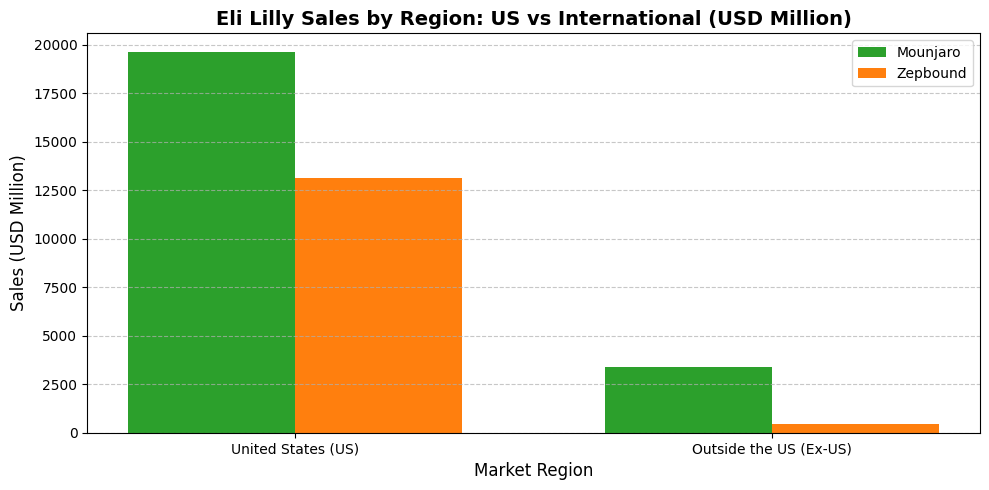

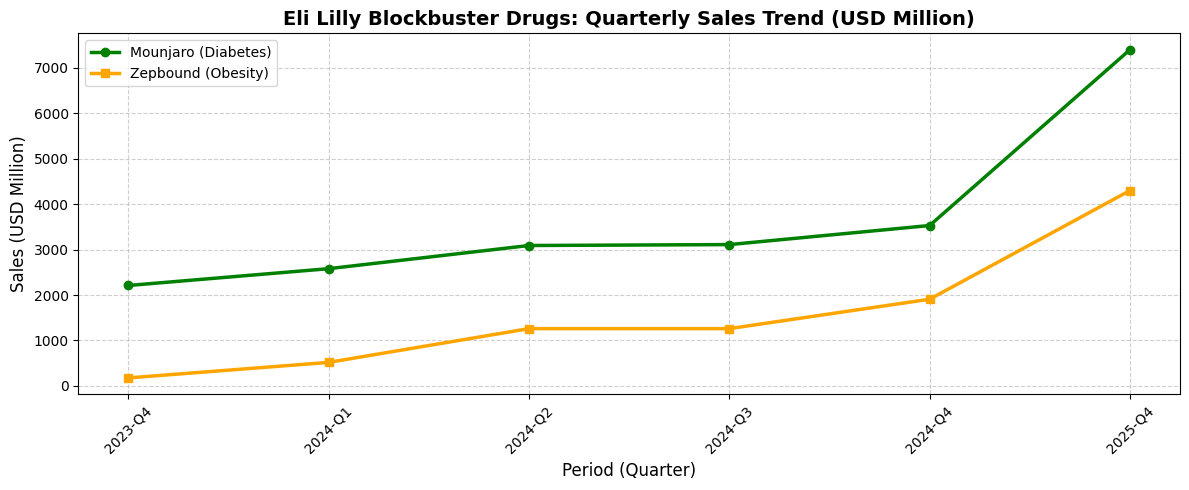

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 마운자로 & 젭바운드 분기별 글로벌 매출 데이터 (단위: USD million)
quarterly_data = {
    'Period': ['2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q4'],
    'Mounjaro': [2210, 2580, 3090, 3110, 3530, 7400],
    'Zepbound': [175, 517, 1260, 1260, 1907, 4300]
}
df_qtr = pd.DataFrame(quarterly_data)

# 2. 지역별(US vs Ex-US) 마운자로 & 젭바운드 매출 구조 데이터 (2025년 기준, 단위: USD million)
regional_data = {
    'Region': ['United States (US)', 'Outside the US (Ex-US)'],
    'Mounjaro_Sales': [19600, 3365],
    'Zepbound_Sales': [13100, 442]
}
df_reg = pd.DataFrame(regional_data)

# --- 시각화 1: 미국 vs 해외 지역별 매출 비교 (Bar Chart) - 위쪽으로 이동 ---
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
x = range(len(df_reg['Region']))

ax.bar([i - bar_width/2 for i in x], df_reg['Mounjaro_Sales'], bar_width, label='Mounjaro', color='#2ca02c')
ax.bar([i + bar_width/2 for i in x], df_reg['Zepbound_Sales'], bar_width, label='Zepbound', color='#ff7f0e')

ax.set_title('Eli Lilly Sales by Region: US vs International (USD Million)', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Region', fontsize=12)
ax.set_ylabel('Sales (USD Million)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_reg['Region'])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 시각화 2: 분기별 매출 성장 추이 (Line Chart) - 아래쪽으로 이동 ---
plt.figure(figsize=(12, 5))
plt.plot(df_qtr['Period'], df_qtr['Mounjaro'], marker='o', color='green', linewidth=2.5, label='Mounjaro (Diabetes)')
plt.plot(df_qtr['Period'], df_qtr['Zepbound'], marker='s', color='orange', linewidth=2.5, label='Zepbound (Obesity)')

plt.title('Eli Lilly Blockbuster Drugs: Quarterly Sales Trend (USD Million)', fontsize=14, fontweight='bold')
plt.xlabel('Period (Quarter)', fontsize=12)
plt.ylabel('Sales (USD Million)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2-2: 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound' 매출 비교

--- 4대 주요 치료제 연도별 매출 비교표 (USD Million) ---


,drug,company,2023_sales_usd,2024_sales_usd,2025_sales_usd
0,Ozempic (Diabetes),Novo Nordisk,13500,20000,18500
1,Wegovy (Obesity),Novo Nordisk,4500,8450,11500
2,Mounjaro (Diabetes),Eli Lilly,5163,11540,23000
3,Zepbound (Obesity),Eli Lilly,180,4920,13500


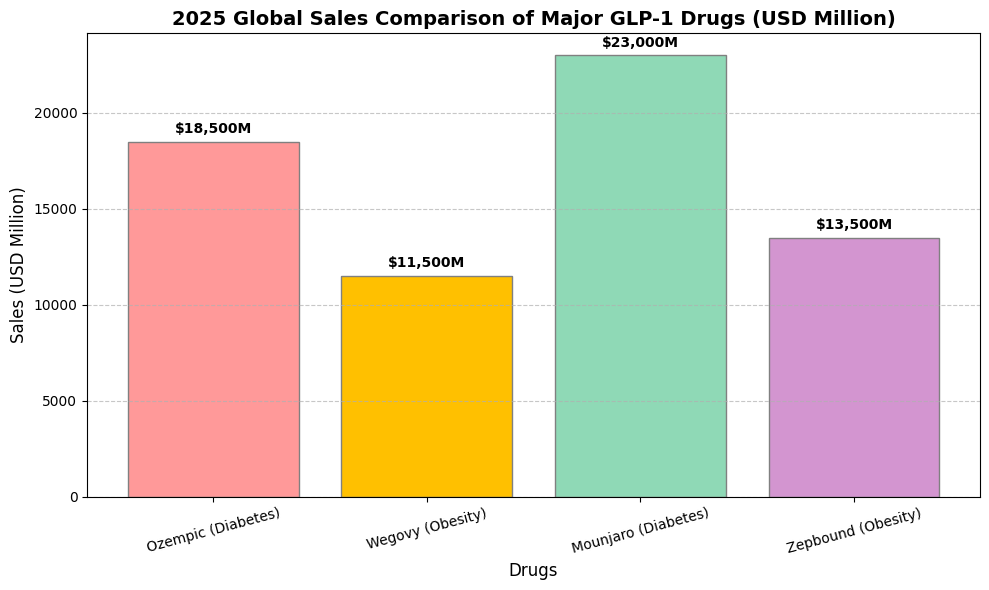

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt

# 1. 4대 주요 비만·당뇨 치료제 연도별 매출 데이터 (단위: USD million)
# (참고: 오젬픽/위고비는 DKK를 USD로 환산, 마운자로/젭바운드는 릴리 공식 실적 기준)
data = """drug,company,2023_sales_usd,2024_sales_usd,2025_sales_usd
Ozempic (Diabetes),Novo Nordisk,13500,20000,18500
Wegovy (Obesity),Novo Nordisk,4500,8450,11500
Mounjaro (Diabetes),Eli Lilly,5163,11540,23000
Zepbound (Obesity),Eli Lilly,180,4920,13500"""

df_drugs = pd.read_csv(io.StringIO(data))
print("--- 4대 주요 치료제 연도별 매출 비교표 (USD Million) ---")
display(df_drugs)

# 2. 2025년 기준 4대 약물 매출 비교 시각화
plt.figure(figsize=(10, 6))
colors = ['#ff9999', '#ffc000', '#8fd9b6', '#d395d0']
bars = plt.bar(df_drugs['drug'], df_drugs['2025_sales_usd'], color=colors, edgecolor='gray')

plt.title("2025 Global Sales Comparison of Major GLP-1 Drugs (USD Million)", fontsize=14, fontweight='bold')
plt.xlabel("Drugs", fontsize=12)
plt.ylabel("Sales (USD Million)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 300,
             f"${height:,.0f}M",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
# 한글 폰트 설치
!apt-get -qq install fonts-nanum

# Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 폰트 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 확인
font = fm.FontProperties(fname=font_path)

print("폰트 설정 완료:", font.get_name())

폰트 설정 완료: NanumGothic


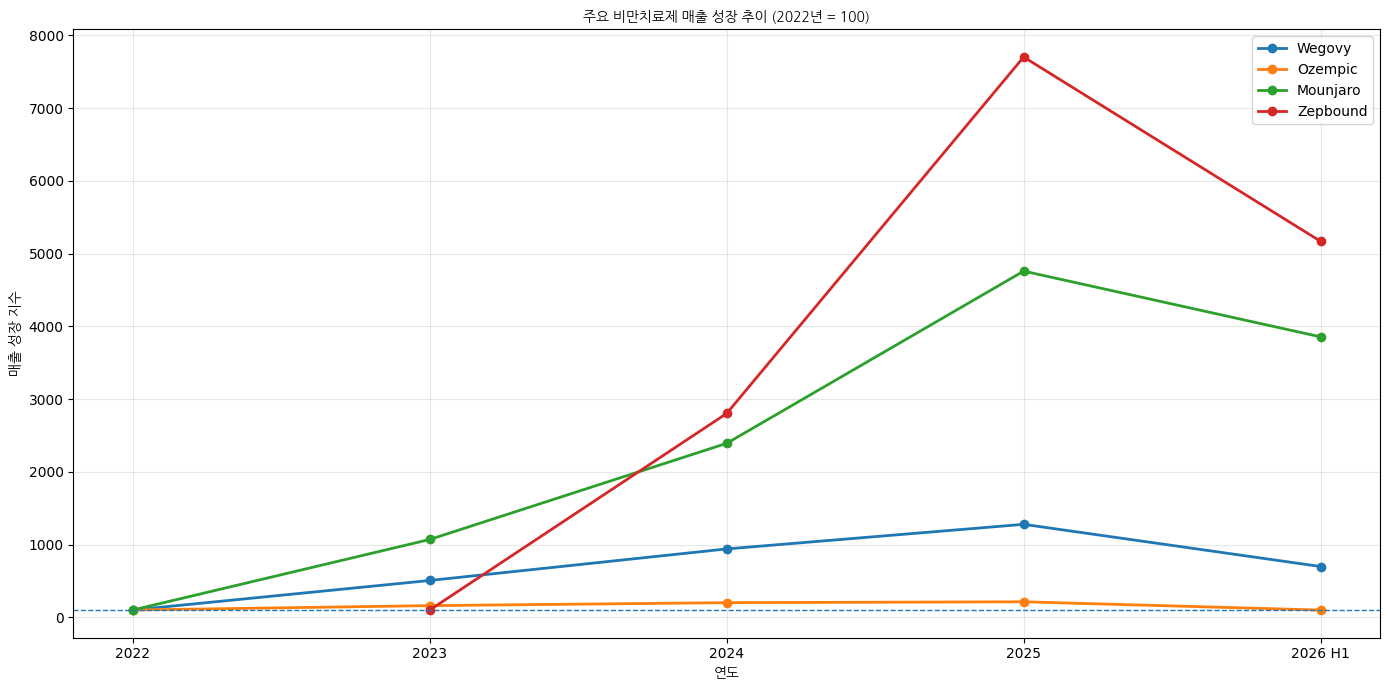

In [6]:
plt.figure(figsize=(14, 7))

drugs = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

for drug in drugs:
    plt.plot(
        sales['year'],
        sales[drug],
        marker='o',
        linewidth=2,
        label=drug
    )

plt.axhline(
    y=100,
    linestyle='--',
    linewidth=1
)

plt.title(
    '주요 비만치료제 매출 성장 추이 (2022년 = 100)',
    fontsize=17,
    fontproperties=font
)

plt.xlabel(
    '연도',
    fontproperties=font
)

plt.ylabel(
    '매출 성장 지수',
    fontproperties=font
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ==========================================
# 1. 한글 폰트 설정
# ==========================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트가 설치되어 있다면 사용
font = fm.FontProperties(fname=font_path)


# ==========================================
# 2. 공식 매출 데이터 입력
# 단위:
# Novo Nordisk = DKK million
# Eli Lilly = USD million
# ==========================================

data = {
    '기간': [
        '2022',
        '2023',
        '2024',
        '2025',
        '2026 H1'
    ],

    'Wegovy_DKK': [
        6188,
        31343,
        58206,
        79106,
        43193
    ],

    'Ozempic_DKK': [
        59750,
        95718,
        120342,
        127089,
        59200
    ],

    'Mounjaro_USD': [
        482.5,
        5163.1,
        11540,
        22965,
        18605
    ],

    'Zepbound_USD': [
        0,
        175.8,
        4926,
        13542,
        9088
    ]
}

sales_df = pd.DataFrame(data)

sales_df

,기간,Wegovy_DKK,Ozempic_DKK,Mounjaro_USD,Zepbound_USD
0,2022,6188,59750,482.5,0.0
1,2023,31343,95718,5163.1,175.8
2,2024,58206,120342,11540.0,4926.0
3,2025,79106,127089,22965.0,13542.0
4,2026 H1,43193,59200,18605.0,9088.0


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =========================
# 한글 폰트 설정
# =========================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = fm.FontProperties(fname=font_path)

# =========================
# 매출 데이터
# 단위
# Novo Nordisk = DKK million
# Eli Lilly = USD million
# =========================

sales_df = pd.DataFrame({
    '기간': ['2022', '2023', '2024', '2025', '2026 H1'],

    'Wegovy': [
        6188,
        31343,
        58206,
        79106,
        43193
    ],

    'Ozempic': [
        59750,
        95718,
        120342,
        127089,
        59200
    ],

    'Mounjaro': [
        482.5,
        5163.1,
        11540,
        22965,
        18605
    ],

    'Zepbound': [
        0,
        175.8,
        4926,
        13542,
        9088
    ]
})

sales_df

,기간,Wegovy,Ozempic,Mounjaro,Zepbound
0,2022,6188,59750,482.5,0.0
1,2023,31343,95718,5163.1,175.8
2,2024,58206,120342,11540.0,4926.0
3,2025,79106,127089,22965.0,13542.0
4,2026 H1,43193,59200,18605.0,9088.0


In [8]:
# =========================
# 성장지수 계산
# =========================

growth_df = sales_df.copy()

# Wegovy: 2022 = 100
growth_df['Wegovy'] = (
    growth_df['Wegovy'] /
    growth_df.loc[0, 'Wegovy'] * 100
)

# Ozempic: 2022 = 100
growth_df['Ozempic'] = (
    growth_df['Ozempic'] /
    growth_df.loc[0, 'Ozempic'] * 100
)

# Mounjaro: 2022 = 100
growth_df['Mounjaro'] = (
    growth_df['Mounjaro'] /
    growth_df.loc[0, 'Mounjaro'] * 100
)

# Zepbound는 2022년 매출이 0
# → 첫 매출 발생 연도인 2023 = 100
growth_df['Zepbound'] = (
    growth_df['Zepbound'] /
    growth_df.loc[1, 'Zepbound'] * 100
)

growth_df

In [9]:
plt.figure(figsize=(14, 8))

for drug in ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']:
    plt.plot(
        growth_df['기간'],
        growth_df[drug],
        marker='o',
        linewidth=2,
        label=drug
    )

# 기준선
plt.axhline(
    100,
    linestyle='--',
    linewidth=1
)

plt.title(
    '주요 비만치료제 매출 성장지수',
    fontsize=18,
    fontproperties=font
)

plt.xlabel(
    '기간',
    fontsize=12,
    fontproperties=font
)

plt.ylabel(
    '매출 성장지수 (기준연도 = 100)',
    fontsize=12,
    fontproperties=font
)

plt.legend(prop=font)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'growth_df' is not defined

<Figure size 1400x800 with 0 Axes>

        기간       Wegovy     Ozempic     Mounjaro     Zepbound
0     2022   100.000000  100.000000   100.000000     0.000000
1     2023   506.512605  160.197490  1070.072539   100.000000
2     2024   940.627020  201.409205  2391.709845  2802.047782
3     2025  1278.377505  212.701255  4759.585492  7703.071672
4  2026 H1   698.012282   99.079498  3855.958549  5169.510808


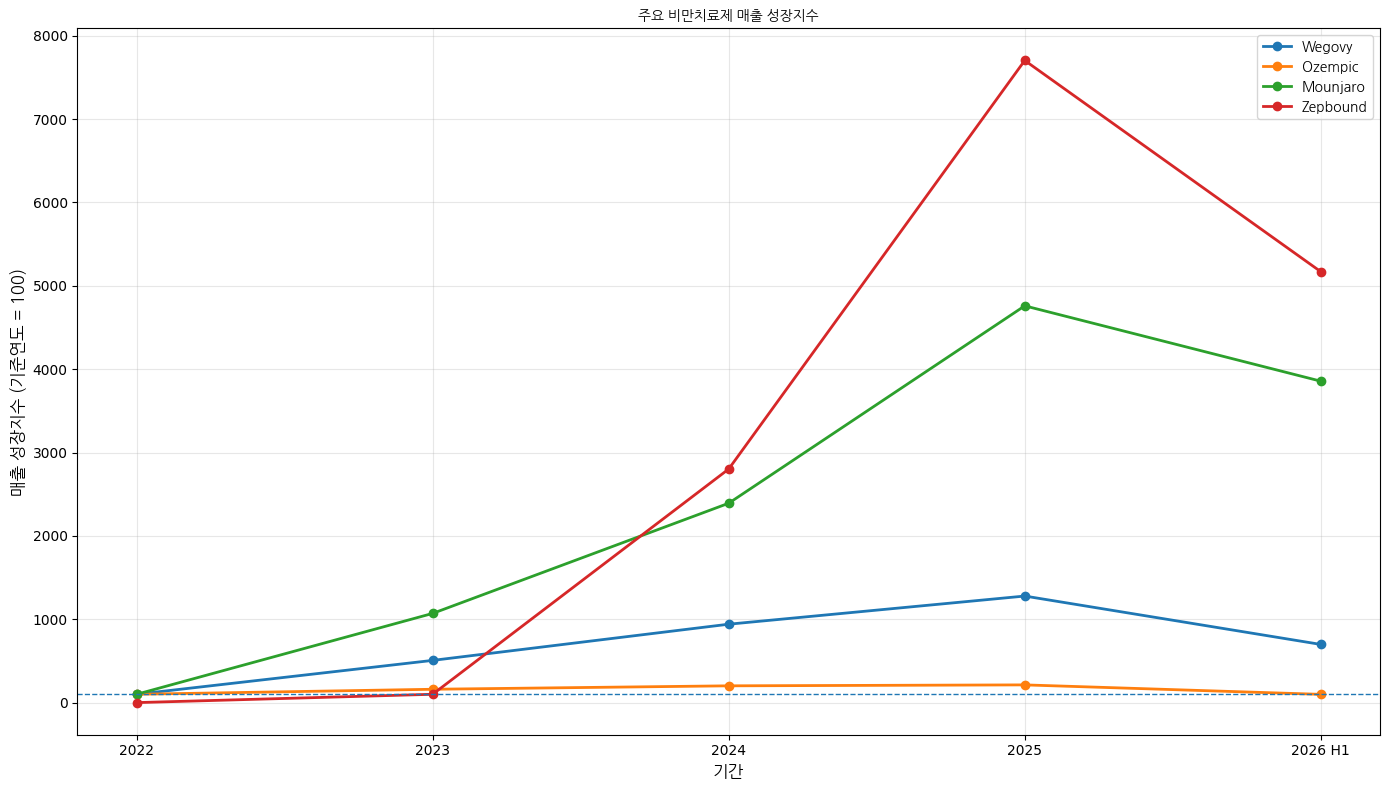

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# =====================================
# 1. 한글 폰트 설정
# =====================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font = fm.FontProperties(fname=font_path)


# =====================================
# 2. 매출 데이터 입력
# =====================================

sales_df = pd.DataFrame({
    '기간': ['2022', '2023', '2024', '2025', '2026 H1'],

    'Wegovy': [
        6188,
        31343,
        58206,
        79106,
        43193
    ],

    'Ozempic': [
        59750,
        95718,
        120342,
        127089,
        59200
    ],

    'Mounjaro': [
        482.5,
        5163.1,
        11540,
        22965,
        18605
    ],

    'Zepbound': [
        0,
        175.8,
        4926,
        13542,
        9088
    ]
})


# =====================================
# 3. 성장지수 계산
# =====================================

growth_df = sales_df.copy()

# Wegovy: 2022년 = 100
growth_df['Wegovy'] = (
    growth_df['Wegovy'] /
    growth_df.loc[0, 'Wegovy'] * 100
)

# Ozempic: 2022년 = 100
growth_df['Ozempic'] = (
    growth_df['Ozempic'] /
    growth_df.loc[0, 'Ozempic'] * 100
)

# Mounjaro: 2022년 = 100
growth_df['Mounjaro'] = (
    growth_df['Mounjaro'] /
    growth_df.loc[0, 'Mounjaro'] * 100
)

# Zepbound: 2023년 = 100
# 2022년에는 매출이 없기 때문
growth_df['Zepbound'] = (
    growth_df['Zepbound'] /
    growth_df.loc[1, 'Zepbound'] * 100
)


# =====================================
# 4. 성장지수 확인
# =====================================

print(growth_df)


# =====================================
# 5. 시각화
# =====================================

plt.figure(figsize=(14, 8))

for drug in ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']:
    plt.plot(
        growth_df['기간'],
        growth_df[drug],
        marker='o',
        linewidth=2,
        label=drug
    )

# 기준선 100
plt.axhline(
    100,
    linestyle='--',
    linewidth=1
)

plt.title(
    '주요 비만치료제 매출 성장지수',
    fontsize=18,
    fontproperties=font
)

plt.xlabel(
    '기간',
    fontsize=12,
    fontproperties=font
)

plt.ylabel(
    '매출 성장지수 (기준연도 = 100)',
    fontsize=12,
    fontproperties=font
)

plt.legend(prop=font)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

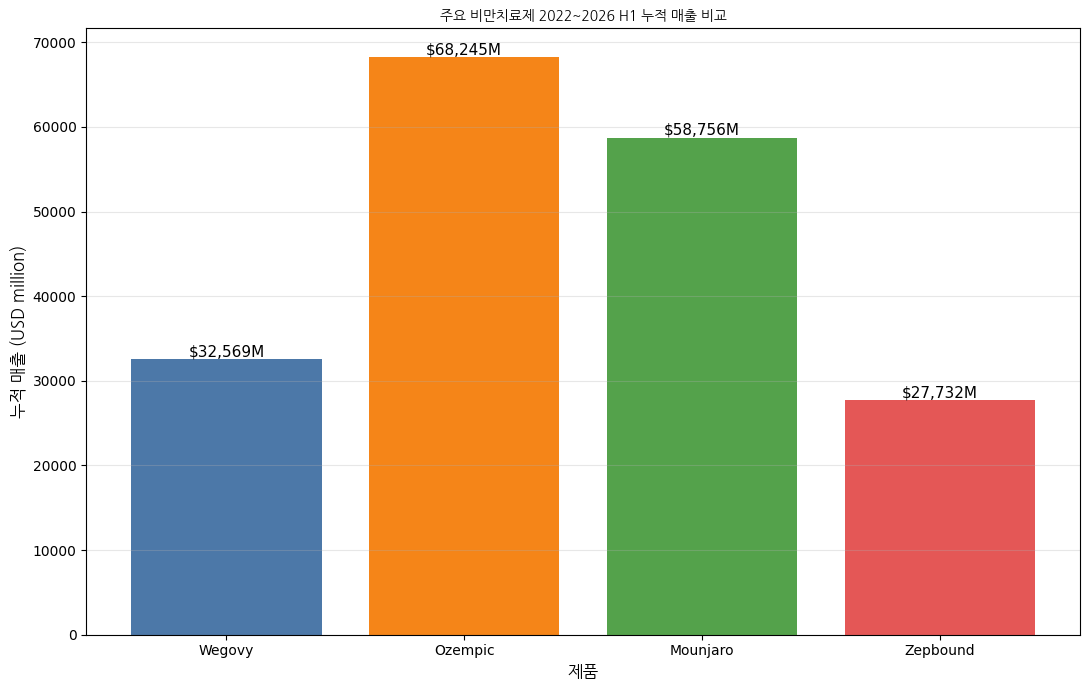

In [14]:
# ==========================================
# 7. 제품별 색상을 다르게 한 막대그래프
# ==========================================

plt.figure(figsize=(11, 7))

colors = [
    '#4C78A8',  # Wegovy
    '#F58518',  # Ozempic
    '#54A24B',  # Mounjaro
    '#E45756'   # Zepbound
]

bars = plt.bar(
    total_df['제품'],
    total_df['누적매출_USD'],
    color=colors
)

plt.title(
    '주요 비만치료제 2022~2026 H1 누적 매출 비교',
    fontsize=18,
    fontproperties=font
)

plt.xlabel(
    '제품',
    fontsize=12,
    fontproperties=font
)

plt.ylabel(
    '누적 매출 (USD million)',
    fontsize=12,
    fontproperties=font
)

# 막대 위에 매출액 표시
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height:,.0f}M',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()

# 2-3: Google Trends API / 데이터: 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound' 'semaglutide', 'GLP-1' 키워드 검색량 (국가별, 주별/분기별)

/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


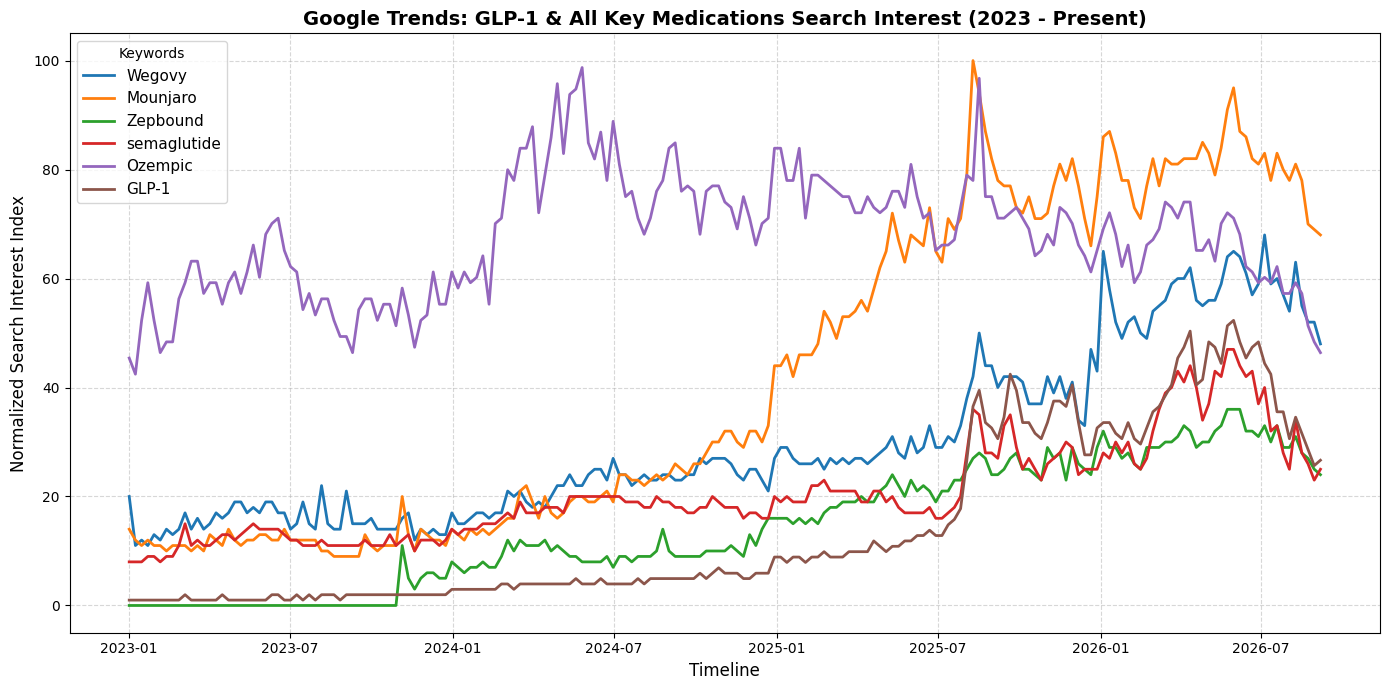

In [ ]:
!pip install pytrends pandas matplotlib -q

import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

pytrend = TrendReq(hl='en-US', tz=540)

# 1차 그룹 (비교 기준이 될 Ozempic 포함)
keywords_group1 = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound', 'semaglutide']
pytrend.build_payload(kw_list=keywords_group1, timeframe='2023-01-01 2026-09-11', geo='')
df1 = pytrend.interest_over_time()

# 2차 그룹 (GLP-1을 비교하기 위해 기준이 되는 Ozempic을 다시 포함)
keywords_group2 = ['Ozempic', 'GLP-1']
pytrend.build_payload(kw_list=keywords_group2, timeframe='2023-01-01 2026-09-11', geo='')
df2 = pytrend.interest_over_time()

if 'isPartial' in df1.columns: df1 = df1.drop(columns=['isPartial'])
if 'isPartial' in df2.columns: df2 = df2.drop(columns=['isPartial'])

# Ozempic의 값을 기준으로 GLP-1의 상대적 스케일을 조정(정규화)
scale_factor = df1['Ozempic'].mean() / df2['Ozempic'].mean()
df2_scaled = df2 * scale_factor

# 데이터 병합 (Ozempic 중복 컬럼 제거 후 합치기)
df_all = pd.concat([df1.drop(columns=['Ozempic']), df2_scaled], axis=1)

# 시각화
plt.figure(figsize=(14, 7))
for col in df_all.columns:
    plt.plot(df_all.index, df_all[col], linewidth=2, label=col)

plt.title('Google Trends: GLP-1 & All Key Medications Search Interest (2023 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Normalized Search Interest Index', fontsize=12)
plt.legend(title='Keywords', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2-4: 키워드 검색량 높은 나라 키워드 점유율

Saving geoMap.csv to geoMap (3).csv


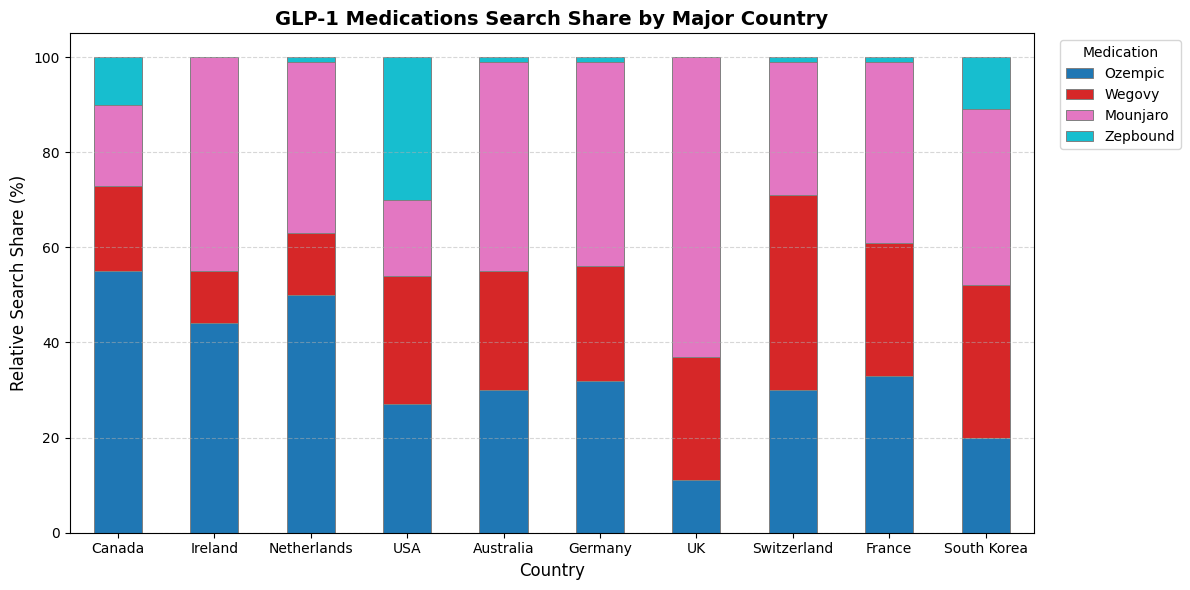

In [ ]:
# 1. 파일 업로드
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

# 2. 데이터 로드 및 정제
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, skiprows=2)
df_cleaned = df.dropna(subset=[df.columns[1]]).copy()

for col in df_cleaned.columns[1:]:
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace('%', '').str.replace('<1', '0').astype(float)

# 주요 제약 시장 국가 필터링 및 영문 매핑
key_countries = ['미국', '영국', '캐나다', '오스트레일리아', '아일랜드', '네덜란드', '독일', '스위스', '프랑스', '대한민국']
country_mapping = {
    '미국': 'USA', '영국': 'UK', '캐나다': 'Canada',
    '오스트레일리아': 'Australia', '아일랜드': 'Ireland',
    '네덜란드': 'Netherlands', '독일': 'Germany',
    '스위스': 'Switzerland', '프랑스': 'France', '대한민국': 'South Korea'
}

df_filtered = df_cleaned[df_cleaned['국가'].isin(key_countries)].copy()
df_filtered['국가'] = df_filtered['국가'].map(country_mapping)
df_filtered = df_filtered.set_index('국가')
df_filtered.columns = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound']

# 3. 누적 막대그래프(Stacked Bar Chart) 시각화
ax = df_filtered.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10', edgecolor='grey', linewidth=0.7)

plt.title('GLP-1 Medications Search Share by Major Country', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Relative Search Share (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Medication', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2-5: 비만치료제 검색량이 높은 주요 10개국의 비만치료제 검색 순위

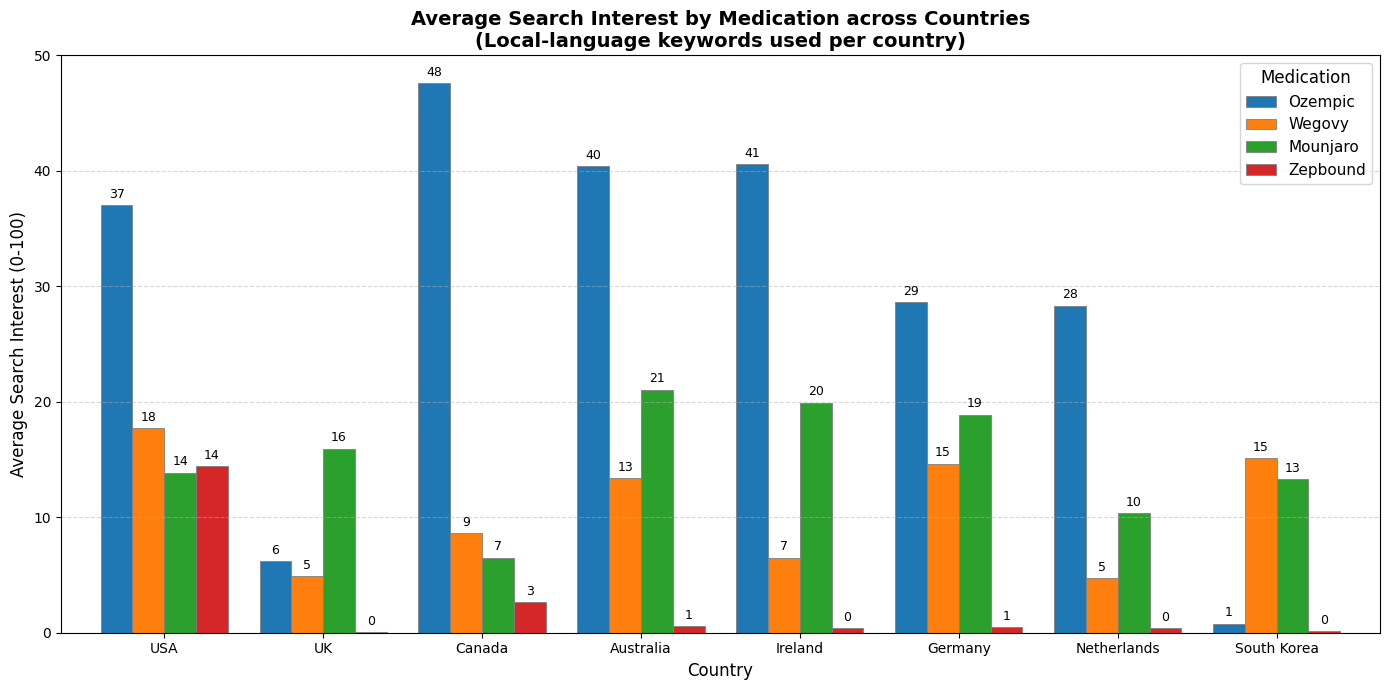

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("trends_by_country_localized.csv", parse_dates=["week"])

# 국가별 · 약품별 평균 검색량 계산
country_avg = df.groupby("country")[["Ozempic", "Wegovy", "Mounjaro", "Zepbound"]].mean()

# 보기 좋게 원하는 국가 순서로 정렬 (선택사항)
country_order = ["USA", "UK", "Canada", "Australia", "Ireland", "Germany", "Netherlands", "South Korea"]
country_avg = country_avg.reindex(country_order)

# 시각화
ax = country_avg.plot(kind='bar', figsize=(14, 7), width=0.8, edgecolor='grey', linewidth=0.6)

plt.title('Average Search Interest by Medication across Countries\n(Local-language keywords used per country)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Average Search Interest (0-100)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Medication', fontsize=11, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("trends_by_country_localized_chart.png", dpi=150)
plt.show()

# 2-6: 뉴스 텍스트 마이닝: 주요 언론사의 위고비 관련 뉴스 기사 크롤링 및 감성 분석 / 키워드 빈도 추출

#2-6-1: pytrends / 데이터: 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound' 등의 키워드 검색량 (국가별, 주별/월별)

In [ ]:
!pip install pytrends -q

In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time
from datetime import datetime

In [ ]:
pytrends = TrendReq(
    hl='en-US',
    tz=360
)

print("Google Trends 연결 준비 완료")

Google Trends 연결 준비 완료


In [ ]:
keywords = [
    'Wegovy',
    'Ozempic',
    'Mounjaro',
    'Zepbound'
]

countries = {
    'US': 'US',
    'UK': 'GB',
    'Germany': 'DE',
    'France': 'FR',
    'Korea': 'KR'
}

timeframe = '2022-01-01 2026-08-31'

print("키워드:", keywords)
print("국가:", list(countries.keys()))
print("기간:", timeframe)

키워드: ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']
국가: ['US', 'UK', 'Germany', 'France', 'Korea']
기간: 2022-01-01 2026-08-31


In [ ]:
all_data = []

for country_name, country_code in countries.items():

    print(f"수집 중: {country_name}")

    try:
        pytrends.build_payload(
            keywords,
            cat=0,
            timeframe=timeframe,
            geo=country_code,
            gprop=''
        )

        data = pytrends.interest_over_time()

        if data.empty:
            print(f"  → 데이터 없음: {country_name}")
            continue

        # isPartial 컬럼 제거
        if 'isPartial' in data.columns:
            data = data.drop(columns=['isPartial'])

        # 날짜를 컬럼으로 변환
        data = data.reset_index()

        # 월 단위로 변환
        data['month'] = data['date'].dt.to_period('M').astype(str)

        # 국가 추가
        data['country'] = country_name

        # 필요한 컬럼만 선택
        data = data[
            ['month', 'country'] + keywords
        ]

        all_data.append(data)

        print(f"  → {len(data)}개 데이터 수집 완료")

        # Google의 요청 제한을 피하기 위한 대기
        time.sleep(10)

    except Exception as e:
        print(f"  → 오류 발생: {e}")
        time.sleep(20)

print("\n수집 종료")

수집 중: US
  → 245개 데이터 수집 완료
수집 중: UK
  → 245개 데이터 수집 완료
수집 중: Germany
  → 245개 데이터 수집 완료
수집 중: France
  → 245개 데이터 수집 완료
수집 중: Korea
  → 245개 데이터 수집 완료

수집 종료


In [ ]:
trends_df = pd.concat(
    all_data,
    ignore_index=True
)

print("전체 데이터 크기:", trends_df.shape)

trends_df.head()

전체 데이터 크기: (1225, 6)


,month,country,Wegovy,Ozempic,Mounjaro,Zepbound
0,2021-12,US,4,6,0,0
1,2022-01,US,4,8,0,0
2,2022-01,US,4,8,0,0
3,2022-01,US,4,8,0,0
4,2022-01,US,4,8,0,0


In [ ]:
trends_df.groupby('country').size()

,0
country,
France,245
Germany,245
Korea,245
UK,245
US,245


In [ ]:
file_name = 'wegovy_google_trends_monthly.csv'

trends_df.to_csv(
    file_name,
    index=False,
    encoding='utf-8-sig'
)

print(f"저장 완료: {file_name}")

저장 완료: wegovy_google_trends_monthly.csv


In [ ]:
from google.colab import files

files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 2-6-2: 데이터 품질 확인

In [ ]:
# 데이터 기본 정보 확인

print("데이터 크기:", trends_df.shape)
print("\n컬럼:")
print(trends_df.columns.tolist())

print("\n국가별 데이터 개수:")
print(trends_df.groupby('country').size())

print("\n결측치:")
print(trends_df.isnull().sum())

print("\n데이터 기간:")
print(trends_df['month'].min(), "~", trends_df['month'].max())

데이터 크기: (1225, 6)

컬럼:
['month', 'country', 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

국가별 데이터 개수:
country
France     245
Germany    245
Korea      245
UK         245
US         245
dtype: int64

결측치:
month       0
country     0
Wegovy      0
Ozempic     0
Mounjaro    0
Zepbound    0
dtype: int64

데이터 기간:
2021-12 ~ 2026-08


In [ ]:
# 중복 확인

duplicate_count = trends_df.duplicated(
    subset=['month', 'country']
).sum()

print("중복 행 개수:", duplicate_count)

중복 행 개수: 940


In [ ]:
# 월 + 국가별로 평균을 내어 월별 데이터로 변환

monthly_trends = (
    trends_df
    .groupby(['month', 'country'])[
        ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']
    ]
    .mean()
    .reset_index()
)

print("월별 데이터 크기:", monthly_trends.shape)

monthly_trends.head(10)

월별 데이터 크기: (285, 6)


,month,country,Wegovy,Ozempic,Mounjaro,Zepbound
0,2021-12,France,0.0,2.0,0.0,0.0
1,2021-12,Germany,0.0,3.0,0.0,0.0
2,2021-12,Korea,0.0,0.0,0.0,0.0
3,2021-12,UK,0.0,1.0,0.0,0.0
4,2021-12,US,4.0,6.0,0.0,0.0
5,2022-01,France,0.0,2.4,0.0,0.0
6,2022-01,Germany,0.0,3.4,0.0,0.0
7,2022-01,Korea,0.0,0.0,0.0,0.0
8,2022-01,UK,0.0,1.0,0.0,0.0
9,2022-01,US,4.0,8.2,0.0,0.0


In [ ]:
duplicate_count = monthly_trends.duplicated(
    subset=['month', 'country']
).sum()

print("월+국가 기준 중복:", duplicate_count)

월+국가 기준 중복: 0


In [ ]:
print("데이터 기간:")
print(monthly_trends['month'].min(), "~", monthly_trends['month'].max())

print("\n국가별 데이터 개수:")
print(monthly_trends.groupby('country').size())

데이터 기간:
2021-12 ~ 2026-08

국가별 데이터 개수:
country
France     57
Germany    57
Korea      57
UK         57
US         57
dtype: int64


In [ ]:
file_name = 'wegovy_google_trends_monthly.csv'

monthly_trends.to_csv(
    file_name,
    index=False,
    encoding='utf-8-sig'
)

print(f"저장 완료: {file_name}")

저장 완료: wegovy_google_trends_monthly.csv


#2-6-3: 국가별 주요 비만치료제 검색 관심도 추이

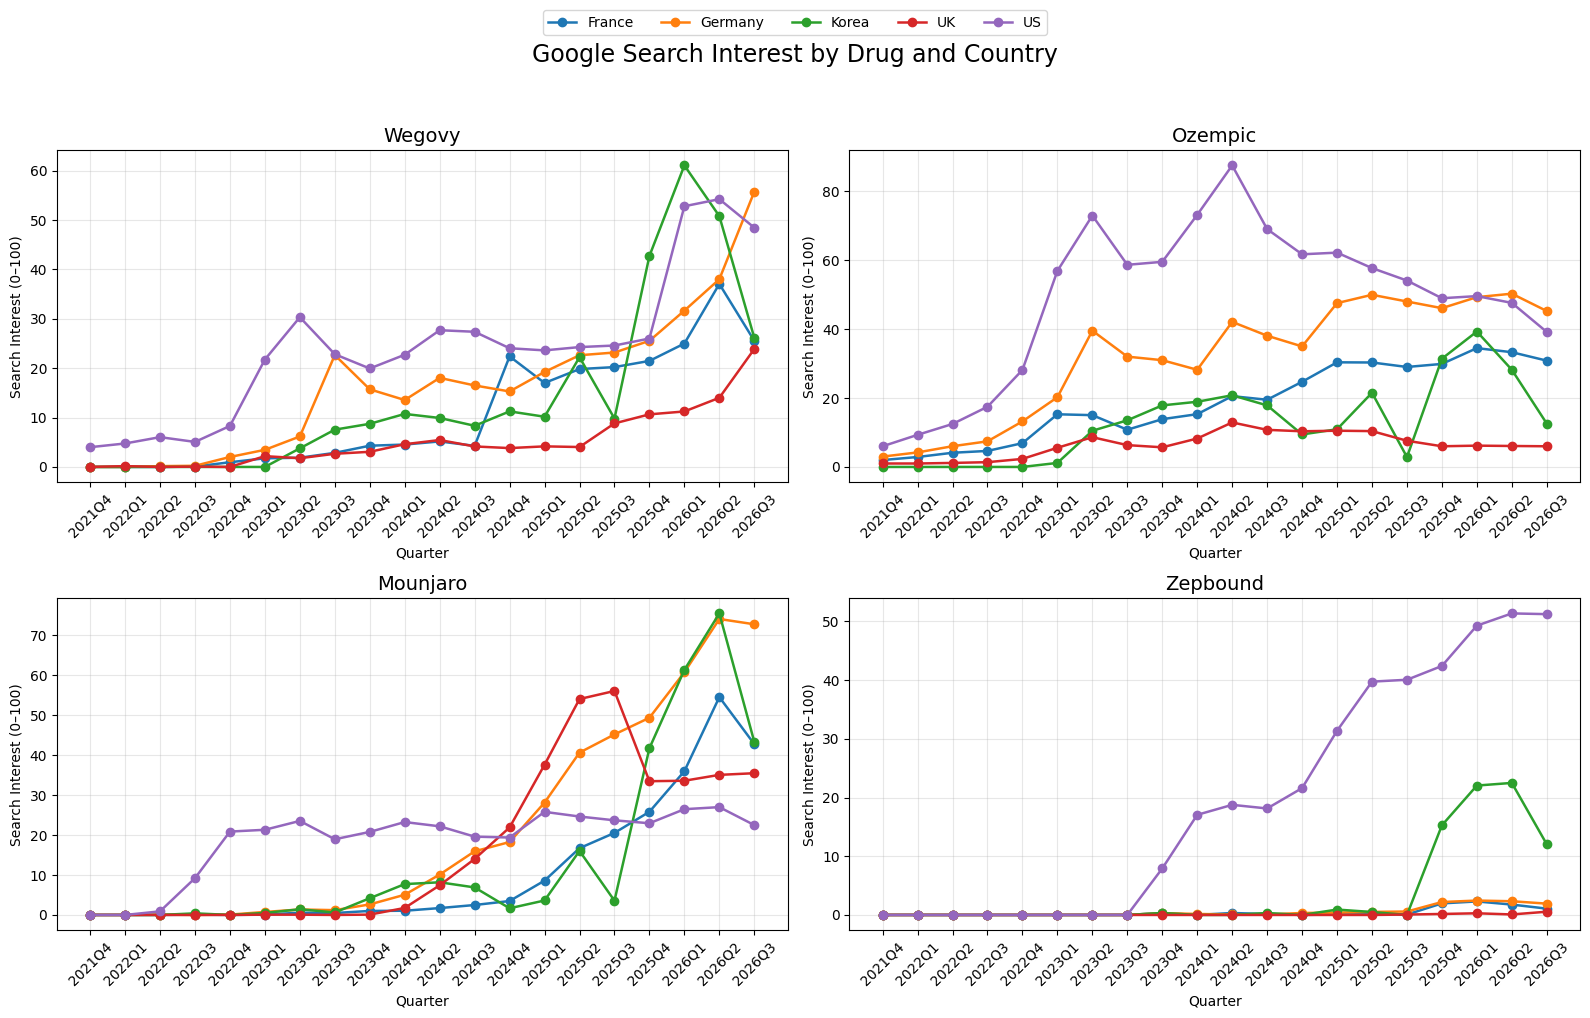

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 날짜 형식 변환
plot_df = monthly_trends.copy()
plot_df['month'] = pd.to_datetime(plot_df['month'])

# 분기 생성
plot_df['quarter'] = plot_df['month'].dt.to_period('Q')

# 국가 + 분기별 평균 검색 관심도
quarterly_trends = (
    plot_df
    .groupby(['quarter', 'country'])[
        ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']
    ]
    .mean()
    .reset_index()
)

# 분기를 그래프에서 사용할 문자열로 변환
quarterly_trends['quarter'] = (
    quarterly_trends['quarter'].astype(str)
)

# 약물 목록
drugs = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

# 그래프
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

axes = axes.flatten()

for i, drug in enumerate(drugs):

    ax = axes[i]

    for country in quarterly_trends['country'].unique():

        country_data = quarterly_trends[
            quarterly_trends['country'] == country
        ].sort_values('quarter')

        ax.plot(
            country_data['quarter'],
            country_data[drug],
            marker='o',
            linewidth=1.8,
            label=country
        )

    ax.set_title(drug, fontsize=14)
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Search Interest (0–100)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

# 전체 그래프에 국가 범례 하나만 표시
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=5,
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle(
    'Google Search Interest by Drug and Country',
    fontsize=17
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

#2-6-4: 치료제별 검색어에 영향을 주는 키워드

# 위고비 관련 키워드 워드클라우드

In [ ]:
# 필요한 라이브러리 설치
!pip install pytrends wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
from wordcloud import WordCloud
import time

In [ ]:
# 기존 분기별 데이터 사용
df = quarterly_trends.copy()

# Wegovy만 선택
wegovy = df[['quarter', 'country', 'Wegovy']].copy()

# 날짜 형식으로 변환
wegovy['quarter'] = pd.PeriodIndex(wegovy['quarter'], freq='Q')

# 미국 데이터만 사용
us_wegovy = wegovy[wegovy['country'] == 'US'].copy()

# 분기별 검색 관심도 변화율 계산
us_wegovy['change_rate'] = (
    us_wegovy['Wegovy'].pct_change() * 100
)

# 급등한 분기 확인
surge_periods = (
    us_wegovy
    .sort_values('change_rate', ascending=False)
    .head(5)
)

surge_periods

,quarter,country,Wegovy,change_rate
29,2023Q1,US,21.750000,162.048193
89,2026Q1,US,52.783333,103.012821
24,2022Q4,US,8.300000,63.815789
34,2023Q2,US,30.316667,39.386973
14,2022Q2,US,6.033333,27.017544


In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(
    hl='en-US',
    tz=360
)

all_related_queries = []

for quarter in surge_periods['quarter']:

    # 분기 시작일 / 종료일
    start_date = quarter.start_time.strftime('%Y-%m-%d')
    end_date = quarter.end_time.strftime('%Y-%m-%d')

    timeframe = f'{start_date} {end_date}'

    print(f'수집 중: {quarter} → {timeframe}')

    try:
        pytrends.build_payload(
            ['Wegovy'],
            timeframe=timeframe,
            geo='US',
            gprop=''
        )

        related = pytrends.related_queries()

        # 연관 검색어가 존재하는 경우
        if related['Wegovy'] is not None:

            top_queries = related['Wegovy']['top']

            if top_queries is not None:

                top_queries = top_queries.copy()

                # 어느 분기의 검색어인지 기록
                top_queries['quarter'] = str(quarter)

                all_related_queries.append(top_queries)

        # Google Trends 요청 간격
        time.sleep(10)

    except Exception as e:
        print(f'{quarter} 수집 실패: {e}')

수집 중: 2023Q1 → 2023-01-01 2023-03-31
수집 중: 2026Q1 → 2026-01-01 2026-03-31
수집 중: 2022Q4 → 2022-10-01 2022-12-31
수집 중: 2023Q2 → 2023-04-01 2023-06-30
수집 중: 2022Q2 → 2022-04-01 2022-06-30


In [ ]:
related_df = pd.concat(
    all_related_queries,
    ignore_index=True
)

related_df.head(20)

,query,value,quarter
0,wegovy weight loss,100,2023Q1
1,ozempic wegovy,92,2023Q1
2,ozempic,91,2023Q1
3,wegovy side effects,55,2023Q1
4,wegovy coupon,46,2023Q1
5,wegovy for weight loss,36,2023Q1
6,mounjaro,33,2023Q1
7,wegovy cost,32,2023Q1
8,ozempic vs wegovy,27,2023Q1
9,what is wegovy,24,2023Q1


In [ ]:
from collections import Counter
import re

# 검색어에서 'wegovy' 제거
clean_keywords = []

for query in related_df['query']:

    # 소문자로 변환
    query = query.lower()

    # wegovy 제거
    query = query.replace('wegovy', '')

    # 남은 단어 추출
    words = re.findall(r'[a-z]+', query)

    # 빈 문자열 제거
    words = [word for word in words if word.strip()]

    clean_keywords.extend(words)


# 단어별 빈도 계산
keyword_counts = Counter(clean_keywords)

# 상위 30개 확인
keyword_counts.most_common(30)

[('weight', 21),
 ('loss', 21),
 ('ozempic', 21),
 ('for', 9),
 ('mounjaro', 6),
 ('cost', 6),
 ('vs', 6),
 ('is', 6),
 ('side', 5),
 ('effects', 5),
 ('coupon', 5),
 ('what', 5),
 ('semaglutide', 5),
 ('reviews', 5),
 ('injection', 5),
 ('how', 5),
 ('saxenda', 4),
 ('prescription', 4),
 ('to', 4),
 ('get', 4),
 ('medication', 4),
 ('near', 4),
 ('me', 4),
 ('online', 4),
 ('bmi', 3),
 ('pill', 3),
 ('price', 3),
 ('shot', 3),
 ('does', 2),
 ('work', 2)]

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# 제거할 불용어
stopwords = {
    'wegovy',
    'for',
    'is',
    'vs',
    'what',
    'how',
    'to',
    'get',
    'near',
    'me',
    'does'
}

# 검색어별 가중치 계산
keyword_scores = {}

for _, row in related_df.iterrows():

    query = row['query'].lower()
    value = row['value']

    # wegovy 제거
    query = query.replace('wegovy', '')

    # 불용어 제거
    words = query.split()
    words = [word for word in words if word not in stopwords]

    # 다시 하나의 검색어로 결합
    cleaned_query = ' '.join(words).strip()

    # 빈 검색어 제외
    if cleaned_query:

        if cleaned_query not in keyword_scores:
            keyword_scores[cleaned_query] = 0

        keyword_scores[cleaned_query] += value


# 상위 검색어 확인
sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:30]

[('ozempic', 702),
 ('weight loss', 666),
 ('side effects', 201),
 ('cost', 158),
 ('coupon', 153),
 ('ozempic weight loss', 133),
 ('mounjaro', 119),
 ('semaglutide', 105),
 ('pill', 100),
 ('saxenda', 84),
 ('reviews', 75),
 ('injection', 70),
 ('prescription', 54),
 ('medication', 48),
 ('price', 42),
 ('online', 39),
 ('zepbound', 35),
 ('shot', 32),
 ('bmi', 31),
 ('dose', 24),
 ('work', 20),
 ('reddit', 20),
 ('pills', 16),
 ('pill cost', 14),
 ('drug', 14),
 ('oral', 13),
 ('ozempic and', 11),
 ('savings card', 11),
 ('mounjaro weight loss', 11),
 ('glp-1', 9)]

In [ ]:
related_df['quarter'].value_counts()

,count
quarter,
2023Q1,25
2026Q1,25
2022Q4,25
2023Q2,25
2022Q2,25


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

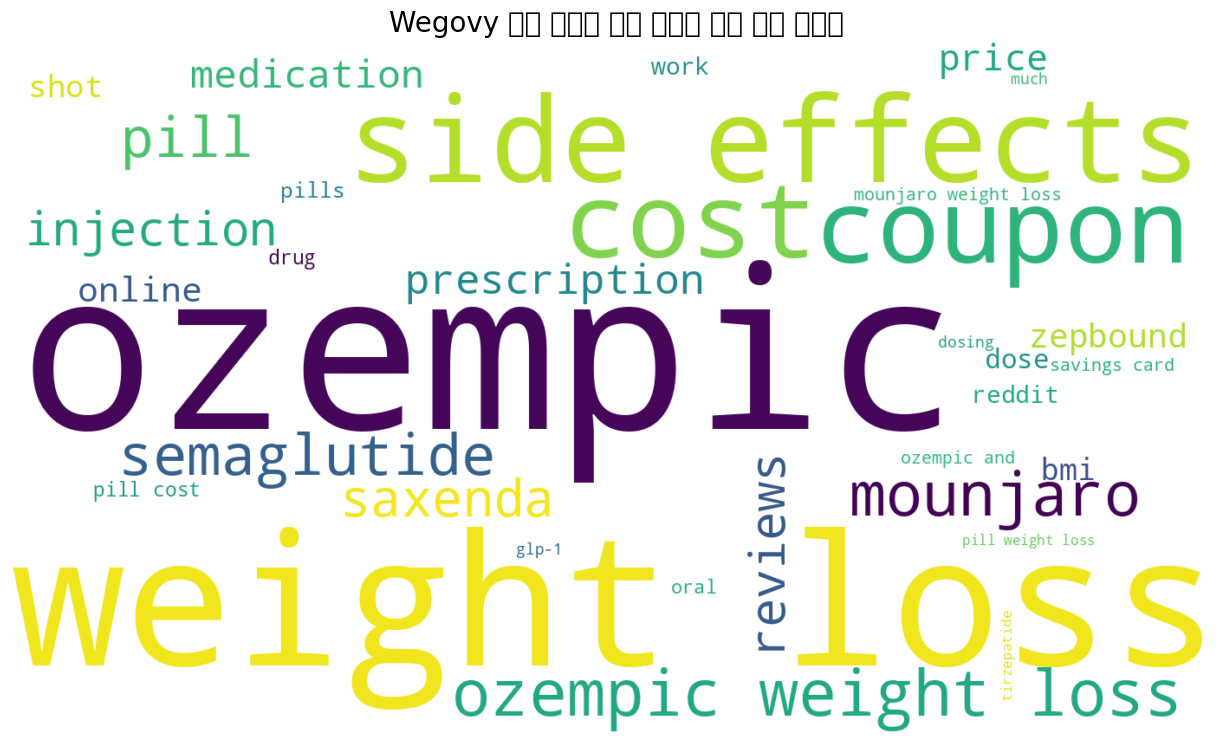

In [ ]:
wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color='white',
    max_words=50,
    collocations=False
)

wc = wordcloud.generate_from_frequencies(keyword_scores)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Wegovy 검색 관심도 급등 시점의 주요 연관 검색어',
    fontsize=20
)

plt.show()

# 오젬픽 관련 키워드 워드클라우드

In [ ]:
df = quarterly_trends.copy()

ozempic = df[['quarter', 'country', 'Ozempic']].copy()
ozempic['quarter'] = pd.PeriodIndex(ozempic['quarter'], freq='Q')

us_ozempic = ozempic[ozempic['country'] == 'US'].copy()

us_ozempic['change_rate'] = us_ozempic['Ozempic'].pct_change() * 100

ozempic_surge_periods = (
    us_ozempic
    .sort_values('change_rate', ascending=False)
    .head(5)
)

ozempic_surge_periods

,quarter,country,Ozempic,change_rate
29,2023Q1,US,56.900000,102.131439
24,2022Q4,US,28.150000,61.164122
9,2022Q1,US,9.316667,55.277778
19,2022Q3,US,17.466667,40.106952
14,2022Q2,US,12.466667,33.810376


In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(hl='en-US', tz=360)

all_ozempic_related = []

for quarter in ozempic_surge_periods['quarter']:
    start_date = quarter.start_time.strftime('%Y-%m-%d')
    end_date = quarter.end_time.strftime('%Y-%m-%d')
    timeframe = f'{start_date} {end_date}'

    print(f'수집 중: {quarter} → {timeframe}')

    try:
        pytrends.build_payload(
            ['Ozempic'],
            timeframe=timeframe,
            geo='US',
            gprop=''
        )

        related = pytrends.related_queries()

        if related['Ozempic'] is not None:
            top_queries = related['Ozempic']['top']

            if top_queries is not None:
                top_queries = top_queries.copy()
                top_queries['quarter'] = str(quarter)
                all_ozempic_related.append(top_queries)

        time.sleep(10)

    except Exception as e:
        print(f'{quarter} 수집 실패: {e}')

ozempic_related_df = pd.concat(
    all_ozempic_related,
    ignore_index=True
)

ozempic_related_df.head(20)

수집 중: 2023Q1 → 2023-01-01 2023-03-31
수집 중: 2022Q4 → 2022-10-01 2022-12-31
수집 중: 2022Q1 → 2022-01-01 2022-03-31
수집 중: 2022Q3 → 2022-07-01 2022-09-30
수집 중: 2022Q2 → 2022-04-01 2022-06-30


,query,value,quarter
0,weight loss ozempic,100,2023Q1
1,ozempic for weight loss,55,2023Q1
2,ozempic side effects,46,2023Q1
3,ozempic face,43,2023Q1
4,wegovy,29,2023Q1
5,what is ozempic,25,2023Q1
6,mounjaro,19,2023Q1
7,ozempic coupon,15,2023Q1
8,ozempic cost,14,2023Q1
9,semaglutide,13,2023Q1


In [ ]:
from collections import Counter

# 의미 없는 표현 제거
stopwords = {
    'ozempic',
    'for',
    'is',
    'vs',
    'what',
    'how',
    'to',
    'get',
    'near',
    'me',
    'and',
}

keyword_scores = {}

for _, row in ozempic_related_df.iterrows():

    query = row['query'].lower()
    value = row['value']

    # 'ozempic' 제거
    query = query.replace('ozempic', '')

    # 단어 단위로 분리
    words = query.split()

    # 불용어 제거
    words = [
        word for word in words
        if word not in stopwords
    ]

    # 다시 하나의 검색어 구문으로 결합
    cleaned_query = ' '.join(words).strip()

    if cleaned_query:
        keyword_scores[cleaned_query] = (
            keyword_scores.get(cleaned_query, 0) + value
        )

# 상위 30개 확인
sorted(
    keyword_scores.items(),
    key=lambda x: x[1],
    reverse=True
)[:30]

[('weight loss', 865),
 ('side effects', 248),
 ('wegovy', 142),
 ('coupon', 94),
 ('cost', 71),
 ('trulicity', 70),
 ('pen', 66),
 ('mounjaro', 61),
 ('dose', 53),
 ('semaglutide', 51),
 ('injection', 51),
 ('face', 43),
 ('metformin', 43),
 ('side effects of', 42),
 ('medication', 41),
 ('reviews', 30),
 ('diabetes', 29),
 ('insulin', 28),
 ('wegovy weight loss', 25),
 ('saxenda', 23),
 ('dosing', 22),
 ('generic', 20),
 ('shot', 14),
 ('prescription', 13),
 ('rybelsus', 8),
 ('reddit', 7),
 ('shortage', 6)]

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

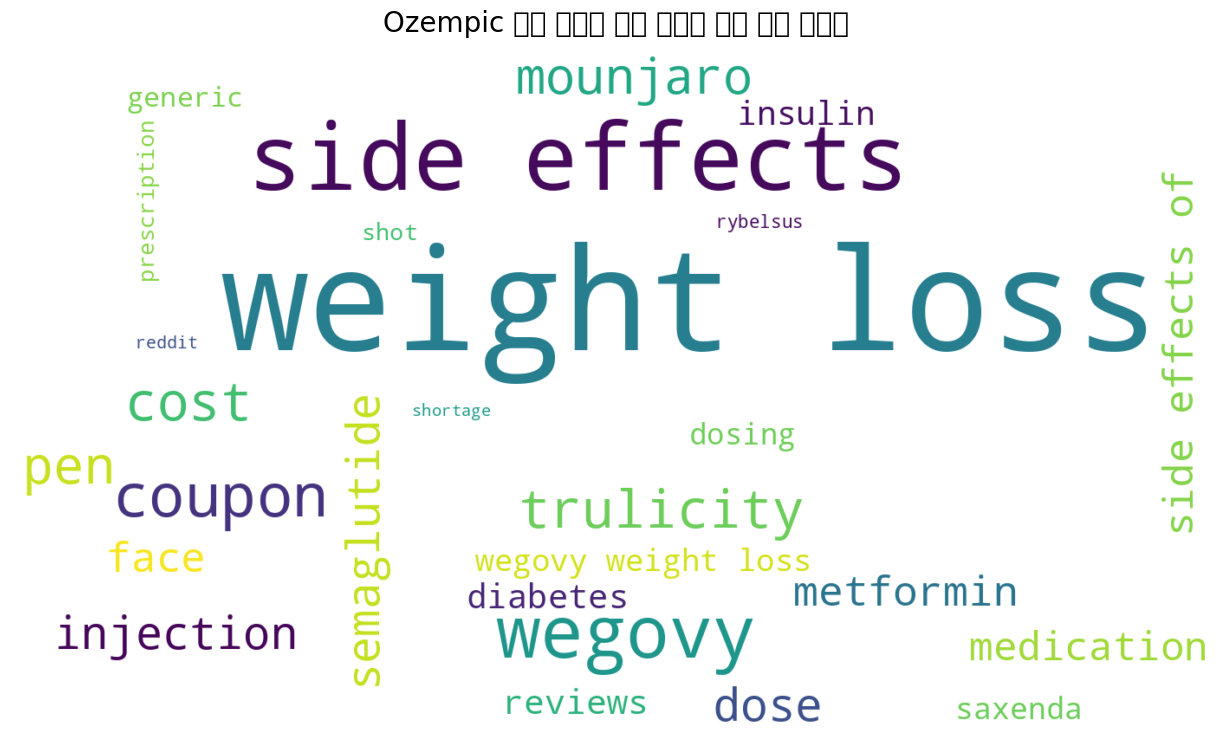

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color='white',
    max_words=50,
    collocations=False
)

wc = wordcloud.generate_from_frequencies(keyword_scores)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Ozempic 검색 관심도 급등 시점의 주요 연관 검색어',
    fontsize=20
)

plt.show()

# 마운자로 관련 키워드 워드클라우드

In [ ]:
df = quarterly_trends.copy()

mounjaro = df[['quarter', 'country', 'Mounjaro']].copy()
mounjaro['quarter'] = pd.PeriodIndex(mounjaro['quarter'], freq='Q')

us_mounjaro = mounjaro[mounjaro['country'] == 'US'].copy()

us_mounjaro['change_rate'] = (
    us_mounjaro['Mounjaro'].pct_change() * 100
)

mounjaro_surge_periods = (
    us_mounjaro
    .sort_values('change_rate', ascending=False)
    .head(5)
)

mounjaro_surge_periods

,quarter,country,Mounjaro,change_rate
14,2022Q2,US,0.900000,inf
19,2022Q3,US,9.200000,922.222222
24,2022Q4,US,20.850000,126.630435
69,2025Q1,US,25.783333,33.132530
89,2026Q1,US,26.450000,15.334302


In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(hl='en-US', tz=360)

all_mounjaro_related = []

for quarter in mounjaro_surge_periods['quarter']:
    start_date = quarter.start_time.strftime('%Y-%m-%d')
    end_date = quarter.end_time.strftime('%Y-%m-%d')
    timeframe = f'{start_date} {end_date}'

    print(f'수집 중: {quarter} → {timeframe}')

    try:
        pytrends.build_payload(
            ['Mounjaro'],
            timeframe=timeframe,
            geo='US',
            gprop=''
        )

        related = pytrends.related_queries()

        if related['Mounjaro'] is not None:
            top_queries = related['Mounjaro']['top']

            if top_queries is not None:
                top_queries = top_queries.copy()
                top_queries['quarter'] = str(quarter)
                all_mounjaro_related.append(top_queries)

        time.sleep(10)

    except Exception as e:
        print(f'{quarter} 수집 실패: {e}')

mounjaro_related_df = pd.concat(
    all_mounjaro_related,
    ignore_index=True
)

mounjaro_related_df.head(20)

수집 중: 2022Q2 → 2022-04-01 2022-06-30
수집 중: 2022Q3 → 2022-07-01 2022-09-30
수집 중: 2022Q4 → 2022-10-01 2022-12-31
수집 중: 2025Q1 → 2025-01-01 2025-03-31
수집 중: 2026Q1 → 2026-01-01 2026-03-31


,query,value,quarter
0,mounjaro weight loss,100,2022Q2
1,tirzepatide,83,2022Q2
2,mounjaro tirzepatide,82,2022Q2
3,mounjaro diabetes,44,2022Q2
4,mounjaro cost,44,2022Q2
5,mounjaro coupon,36,2022Q2
6,mounjaro lilly,34,2022Q2
7,lilly,32,2022Q2
8,mounjaro for weight loss,32,2022Q2
9,ozempic,30,2022Q2


In [ ]:
from collections import Counter

stopwords = {
    'mounjaro',
    'for',
    'is',
    'vs',
    'what',
    'how',
    'to',
    'get',
    'near',
    'me',
    'and'
}

keyword_scores = {}

for _, row in mounjaro_related_df.iterrows():

    query = row['query'].lower()
    value = row['value']

    # 'mounjaro' 제거
    query = query.replace('mounjaro', '')

    # 불용어 제거
    words = query.split()
    words = [
        word for word in words
        if word not in stopwords
    ]

    # 검색어 구문 유지
    cleaned_query = ' '.join(words).strip()

    if cleaned_query:
        keyword_scores[cleaned_query] = (
            keyword_scores.get(cleaned_query, 0) + value
        )

# 상위 30개 확인
sorted(
    keyword_scores.items(),
    key=lambda x: x[1],
    reverse=True
)[:30]

[('weight loss', 657),
 ('tirzepatide', 460),
 ('ozempic', 330),
 ('coupon', 260),
 ('side effects', 247),
 ('zepbound', 171),
 ('cost', 139),
 ('wegovy', 136),
 ('recipe', 100),
 ('price', 96),
 ('injection', 74),
 ('medication', 72),
 ('dose', 70),
 ('diabetes', 67),
 ('lilly', 66),
 ('natural', 65),
 ('reviews', 54),
 ('savings card', 51),
 ('side effects of', 48),
 ('natural recipe', 43),
 ('eli lilly', 37),
 ('cost of', 34),
 ('drug', 30),
 ('reddit', 30),
 ('prescription', 27),
 ('brazilian recipe', 25),
 ('trulicity', 24),
 ('semaglutide', 22),
 ('ingredients', 22),
 ('glp-1', 21)]

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

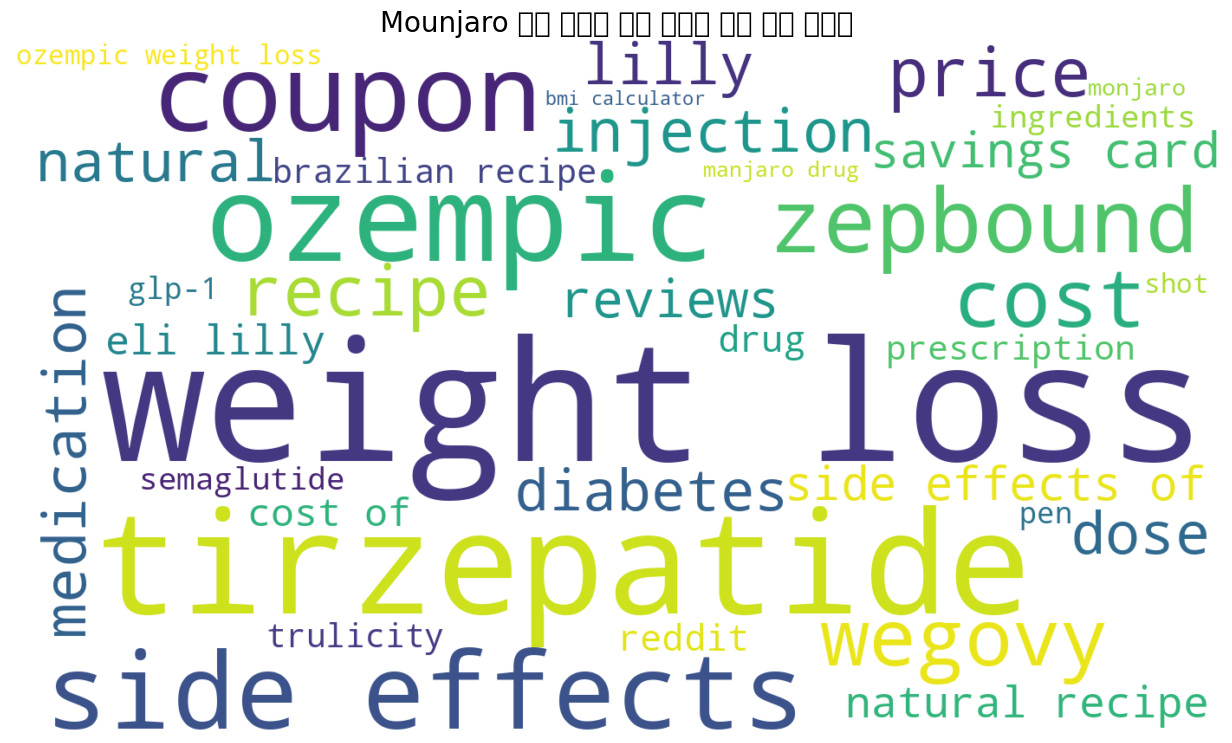

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color='white',
    max_words=50,
    collocations=False
)

wc = wordcloud.generate_from_frequencies(keyword_scores)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Mounjaro 검색 관심도 급등 시점의 주요 연관 검색어',
    fontsize=20
)

plt.show()

# 젭바운드 관련 키워드 워드클라우드

In [ ]:
df = quarterly_trends.copy()

zepbound = df[['quarter', 'country', 'Zepbound']].copy()
zepbound['quarter'] = pd.PeriodIndex(zepbound['quarter'], freq='Q')

us_zepbound = zepbound[zepbound['country'] == 'US'].copy()

us_zepbound['change_rate'] = (
    us_zepbound['Zepbound'].pct_change() * 100
)

zepbound_surge_periods = (
    us_zepbound
    .sort_values('change_rate', ascending=False)
    .head(5)
)

zepbound_surge_periods

,quarter,country,Zepbound,change_rate
44,2023Q4,US,7.916667,inf
49,2024Q1,US,17.050000,115.368421
69,2025Q1,US,31.366667,45.216049
74,2025Q2,US,39.733333,26.673751
64,2024Q4,US,21.600000,19.117647


In [ ]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(hl='en-US', tz=360)

all_zepbound_related = []

for quarter in zepbound_surge_periods['quarter']:
    start_date = quarter.start_time.strftime('%Y-%m-%d')
    end_date = quarter.end_time.strftime('%Y-%m-%d')
    timeframe = f'{start_date} {end_date}'

    print(f'수집 중: {quarter} → {timeframe}')

    try:
        pytrends.build_payload(
            ['Zepbound'],
            timeframe=timeframe,
            geo='US',
            gprop=''
        )

        related = pytrends.related_queries()

        if related['Zepbound'] is not None:
            top_queries = related['Zepbound']['top']

            if top_queries is not None:
                top_queries = top_queries.copy()
                top_queries['quarter'] = str(quarter)
                all_zepbound_related.append(top_queries)

        time.sleep(10)

    except Exception as e:
        print(f'{quarter} 수집 실패: {e}')

zepbound_related_df = pd.concat(
    all_zepbound_related,
    ignore_index=True
)

zepbound_related_df.head(20)

수집 중: 2023Q4 → 2023-10-01 2023-12-31
수집 중: 2024Q1 → 2024-01-01 2024-03-31
수집 중: 2025Q1 → 2025-01-01 2025-03-31
수집 중: 2025Q2 → 2025-04-01 2025-06-30
수집 중: 2024Q4 → 2024-10-01 2024-12-31


,query,value,quarter
0,zepbound weight loss,100,2023Q4
1,zepbound coupon,57,2023Q4
2,mounjaro,57,2023Q4
3,zepbound cost,35,2023Q4
4,zepbound savings card,33,2023Q4
5,wegovy,31,2023Q4
6,zepbound for weight loss,24,2023Q4
7,what is zepbound,19,2023Q4
8,ozempic,19,2023Q4
9,lilly zepbound,17,2023Q4


In [ ]:
from collections import Counter

stopwords = {
    'zepbound',
    'for',
    'is',
    'vs',
    'what',
    'how',
    'to',
    'get',
    'near',
    'me',
    'and'
}

keyword_scores = {}

for _, row in zepbound_related_df.iterrows():

    query = row['query'].lower()
    value = row['value']

    # 'zepbound' 제거
    query = query.replace('zepbound', '')

    # 불용어 제거
    words = query.split()
    words = [
        word for word in words
        if word not in stopwords
    ]

    # 검색어 구문 유지
    cleaned_query = ' '.join(words).strip()

    if cleaned_query:
        keyword_scores[cleaned_query] = (
            keyword_scores.get(cleaned_query, 0) + value
        )

# 상위 30개 확인
sorted(
    keyword_scores.items(),
    key=lambda x: x[1],
    reverse=True
)[:30]

[('weight loss', 558),
 ('wegovy', 520),
 ('mounjaro', 370),
 ('side effects', 361),
 ('coupon', 330),
 ('lilly', 300),
 ('cost', 237),
 ('ozempic', 216),
 ('tirzepatide', 204),
 ('reddit', 200),
 ('savings card', 183),
 ('lilly direct', 131),
 ('dose', 123),
 ('injection', 115),
 ('sleep apnea', 111),
 ('eli lilly', 98),
 ('medication', 75),
 ('without insurance', 64),
 ('semaglutide', 61),
 ('direct', 46),
 ('savings', 45),
 ('much', 39),
 ('reviews', 33),
 ('doses', 18),
 ('prescription', 17),
 ('stock', 9),
 ('price', 8)]

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

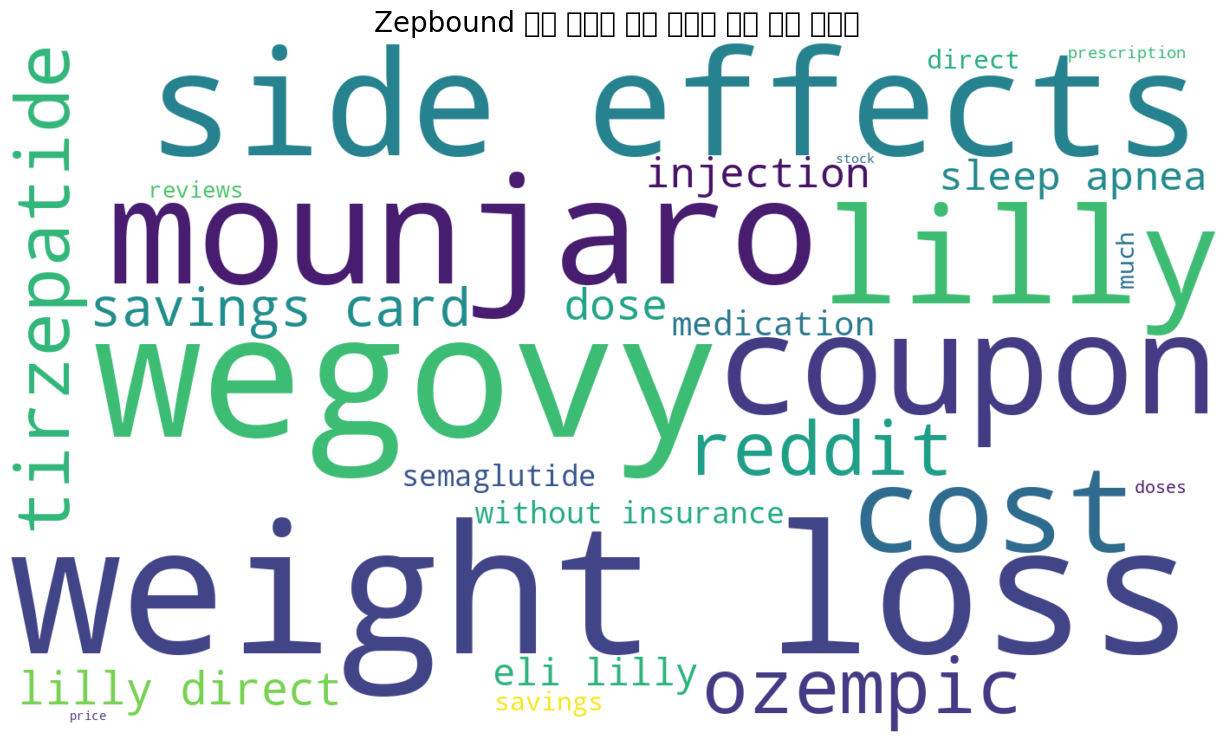

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=1400,
    height=800,
    background_color='white',
    max_words=50,
    collocations=False
)

wc = wordcloud.generate_from_frequencies(keyword_scores)

plt.figure(figsize=(16, 9))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')

plt.title(
    'Zepbound 검색 관심도 급등 시점의 주요 연관 검색어',
    fontsize=20
)

plt.show()

# 2-6: 키워드 검색량에 따른 매출 증가 추세

--- 4대 GLP-1 치료제 개별 구글 트렌드 검색량 수집 중... ---


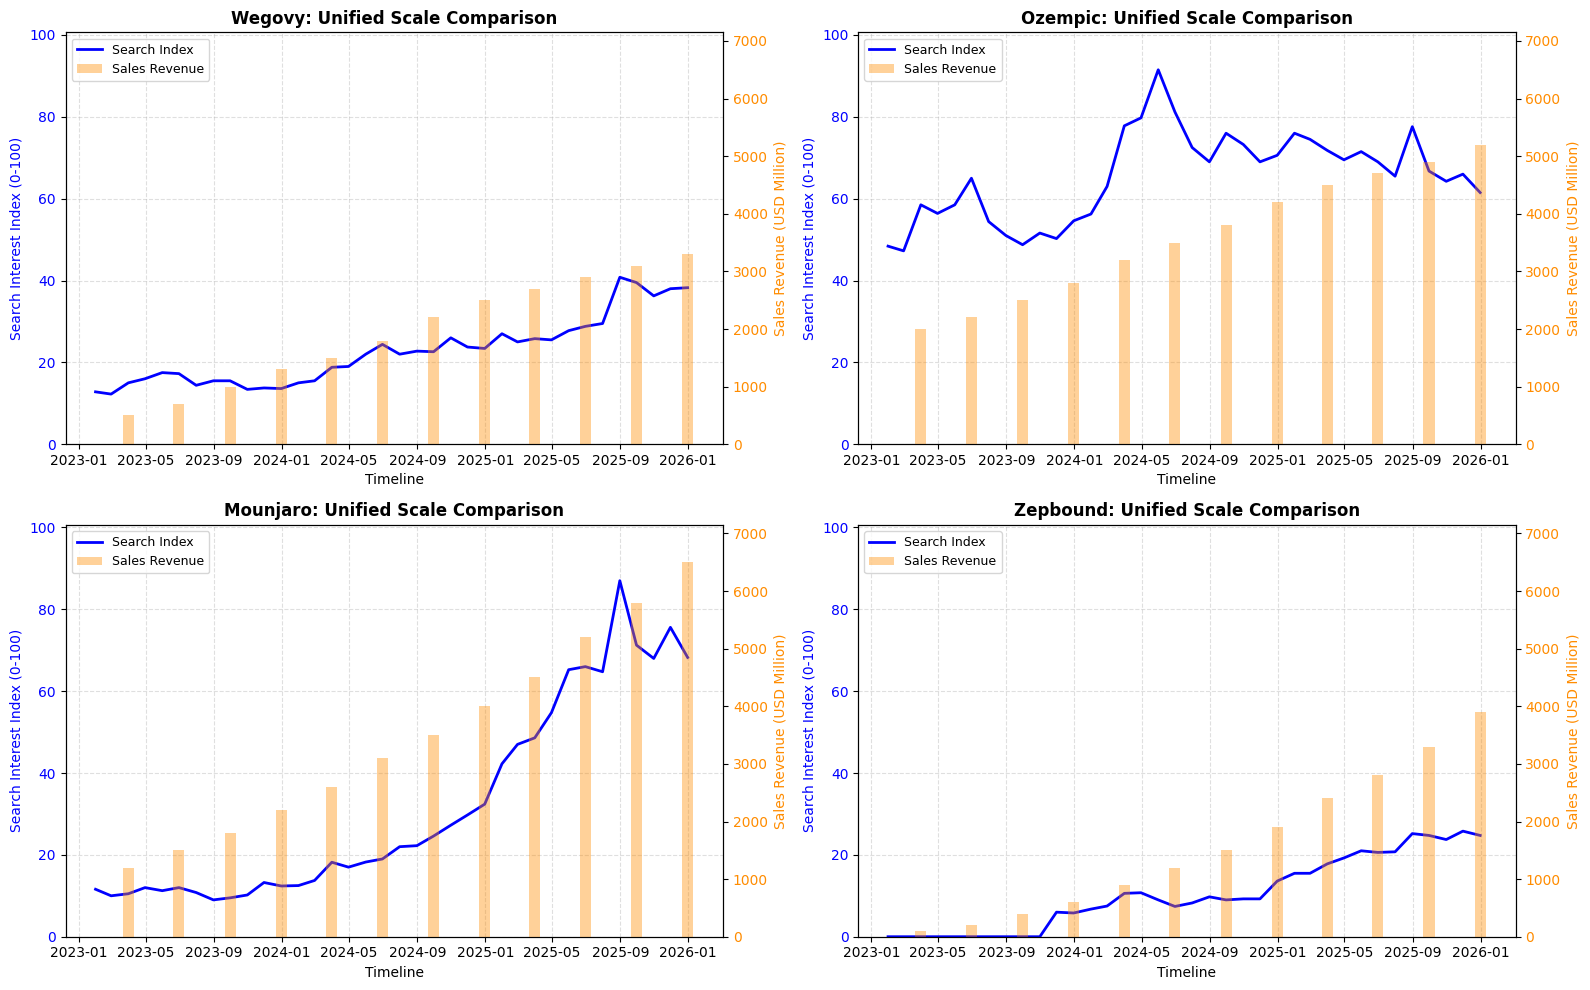

In [ ]:
# 1. 필수 라이브러리 설치 및 임포트
!pip install pytrends pandas matplotlib -q

import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

# 2. 4가지 주요 약물 구글 트렌드 검색량 데이터 수집
pytrend = TrendReq(hl='en-US', tz=540)
keywords = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

print("--- 4대 GLP-1 치료제 개별 구글 트렌드 검색량 수집 중... ---")
pytrend.build_payload(kw_list=keywords, timeframe='2023-01-01 2025-12-31', geo='')
df_trends = pytrend.interest_over_time()

if 'isPartial' in df_trends.columns:
    df_trends = df_trends.drop(columns=['isPartial'])

# 월별 평균 검색 관심도로 리샘플링
df_trends_monthly = df_trends.resample('ME').mean()

# 3. 제품별 분기 매출 데이터 프레임 구축 (단위: USD Million)
quarters = pd.to_datetime(['2023-03-31', '2023-06-30', '2023-09-30', '2023-12-31',
                           '2024-03-31', '2024-06-30', '2024-09-30', '2024-12-31',
                           '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-31'])

sales_dict = {
    'Ozempic': [2000, 2200, 2500, 2800, 3200, 3500, 3800, 4200, 4500, 4700, 4900, 5200],
    'Wegovy':  [500,  700,  1000, 1300, 1500, 1800, 2200, 2500, 2700, 2900, 3100, 3300],
    'Mounjaro':[1200, 1500, 1800, 2200, 2600, 3100, 3500, 4000, 4500, 5200, 5800, 6500],
    'Zepbound':[100,  200,  400,  600,  900,  1200, 1500, 1900, 2400, 2800, 3300, 3900]
}
df_sales = pd.DataFrame(sales_dict, index=quarters)

# 4개 그래프 간의 동일한 축 범위를 위해 전체 데이터의 최댓값 기준 산정
max_search = df_trends_monthly[keywords].max().max() * 1.1
max_sales = df_sales.max().max() * 1.1

# --- 4. 2x2 서브플롯 (동일한 Y축 스케일 적용) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, kw in enumerate(keywords):
    ax1 = axes[i]

    # [왼쪽 축]: 검색 트렌드 (파란색 선) - 모든 그래프 동일 범위 적용
    ax1.set_title(f'{kw}: Unified Scale Comparison', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Timeline', fontsize=10)
    ax1.set_ylabel('Search Interest Index (0-100)', color='blue', fontsize=10)
    ax1.plot(df_trends_monthly.index, df_trends_monthly[kw], color='blue', linewidth=2, label='Search Index')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim(0, max_search)  # 👈 모든 그래프의 검색량 축 범위를 동일하게 고정
    ax1.grid(True, linestyle='--', alpha=0.4)

    # [오른쪽 축]: 실제 매출액 (주황색 막대) - 모든 그래프 동일 범위 적용
    ax2 = ax1.twinx()
    ax2.set_ylabel('Sales Revenue (USD Million)', color='darkorange', fontsize=10)
    ax2.bar(df_sales.index, df_sales[kw], width=20, color='darkorange', alpha=0.4, label='Sales Revenue')
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, max_sales)  # 👈 모든 그래프의 매출액 축 범위를 동일하게 고정

    # 각 서브플롯별 범례 통합
    lines, labels = ax1.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax1.legend(lines + bars, labels + bar_labels, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# 3-1: 뉴스 텍스트 마이닝: 주요 언론사의 위고비 관련 뉴스 기사 크롤링 및 감성 분석 / 키워드 빈도 추출






In [ ]:
!pip install pytrends vaderSentiment scikit-learn pandas requests

In [ ]:
# -*- coding: utf-8 -*-
"""
01_pytrends_collect.py
------------------------------------------------
Wegovy / Ozempic / Mounjaro / Zepbound 등의
Google Trends 검색량(국가별, 주별/월별)을 수집하는 스크립트

설치 (Colab 셀에서 실행):
    !pip install pytrends pandas

주의사항:
- pytrends는 공식 API가 아니라 Google Trends 웹페이지를 흉내내는 비공식 라이브러리라
  요청이 너무 잦으면 429(Too Many Requests) 에러가 납니다.
  -> time.sleep()으로 요청 간 딜레이를 꼭 넣어주세요.
- 국가 코드는 ISO-2 (예: 'US', 'KR', 'GB', 'DE', 'JP' ...) 를 사용합니다.
- 한 번의 요청에 키워드는 최대 5개까지만 비교 가능합니다.
"""

import time
import pandas as pd
from pytrends.request import TrendReq

KEYWORDS = ["Wegovy", "Ozempic", "Mounjaro", "Zepbound"]

COUNTRIES = {
    "United States": "US",
    "South Korea": "KR",
    "United Kingdom": "GB",
    "Germany": "DE",
    "Japan": "JP",
    "Canada": "CA",
    "Australia": "AU",
}

TIMEFRAME = "2020-01-01 2026-09-01"

OUTPUT_GLOBAL = "trends_global_weekly.csv"
OUTPUT_BY_COUNTRY = "trends_by_country_weekly.csv"


def collect_global_trend(pytrends, keywords, timeframe):
    """국가 구분 없이(전세계) 주간 검색량 수집"""
    pytrends.build_payload(keywords, timeframe=timeframe, geo="")
    df = pytrends.interest_over_time()
    if "isPartial" in df.columns:
        df = df.drop(columns=["isPartial"])
    df = df.reset_index().rename(columns={"date": "week"})
    df["geo"] = "GLOBAL"
    return df


def collect_by_country(pytrends, keywords, timeframe, countries: dict):
    """국가별로 반복 수집 후 하나의 DataFrame으로 합침"""
    all_rows = []
    for country_name, geo_code in countries.items():
        try:
            pytrends.build_payload(keywords, timeframe=timeframe, geo=geo_code)
            df = pytrends.interest_over_time()
            if df.empty:
                print(f"[경고] {country_name}({geo_code}) 데이터 없음, 건너뜀")
                continue
            if "isPartial" in df.columns:
                df = df.drop(columns=["isPartial"])
            df = df.reset_index().rename(columns={"date": "week"})
            df["country"] = country_name
            df["geo"] = geo_code
            all_rows.append(df)
            print(f"[완료] {country_name}({geo_code}) 수집 완료 ({len(df)}행)")
        except Exception as e:
            print(f"[에러] {country_name}({geo_code}) 수집 실패: {e}")
        finally:
            time.sleep(3)
    if not all_rows:
        return pd.DataFrame()
    return pd.concat(all_rows, ignore_index=True)


def main():
    pytrends = TrendReq(hl="en-US", tz=0)

    print("== 전세계 기준 검색량 수집 중 ==")
    global_df = collect_global_trend(pytrends, KEYWORDS, TIMEFRAME)
    global_df.to_csv(OUTPUT_GLOBAL, index=False, encoding="utf-8-sig")
    print(f"저장 완료: {OUTPUT_GLOBAL} ({len(global_df)}행)")

    print("\n== 국가별 검색량 수집 중 ==")
    country_df = collect_by_country(pytrends, KEYWORDS, TIMEFRAME, COUNTRIES)
    if not country_df.empty:
        country_df.to_csv(OUTPUT_BY_COUNTRY, index=False, encoding="utf-8-sig")
        print(f"저장 완료: {OUTPUT_BY_COUNTRY} ({len(country_df)}행)")
    else:
        print("국가별 데이터 수집 실패 - 네트워크/요청 제한을 확인하세요.")


if __name__ == "__main__":
    main()

== 전세계 기준 검색량 수집 중 ==
저장 완료: trends_global_weekly.csv (81행)

== 국가별 검색량 수집 중 ==


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)
/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[완료] United States(US) 수집 완료 (81행)


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[완료] South Korea(KR) 수집 완료 (81행)


...

[완료] Japan(JP) 수집 완료 (81행)


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[완료] Canada(CA) 수집 완료 (81행)


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[완료] Australia(AU) 수집 완료 (81행)
저장 완료: trends_by_country_weekly.csv (567행)


In [ ]:
import os
print(os.listdir())

['.config', 'glp1_trends_weekly_by_country_2026.csv', 'wegovy_ml_master_dataset.csv', 'glp1_trends_by_country_comparison.png', 'glp1_trends_monthly_by_country_2026.csv', 'wegovy_analysis_timeline.png', 'wegovy_final_visualization.png', 'glp1_comprehensive_events_v2.png', 'glp1_trends_weekly_by_country.csv', 'glp1_trends_korea_detailed.png', 'glp1_comprehensive_events.png', '03_event_log.csv', 'glp1_events_heatmap.png', 'glp1_trends_monthly_by_country.csv', 'wegovy_analysis_timeline_fixed.png', 'trends_by_country_weekly.csv', 'wegovy_google_trends.csv', 'trends_global_weekly.csv', 'glp1_trends_korea_kr_en.csv', 'sample_data']


In [ ]:
raw_df, sentiment_df, freq_df = collect_and_save_news()

== [단계 A] GDELT 뉴스 수집 중 ==
'Wegovy' 키워드로 250건 수집


HTTPError: 429 Client Error: Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=semaglutide+weight+loss&mode=artlist&format=json&startdatetime=20210101000000&enddatetime=20260901000000&maxrecords=250&sort=datedesc

In [ ]:
import time
import requests
import pandas as pd

def collect_from_gdelt(keyword: str, start_date: str, end_date: str, max_records: int = 250,
                        max_retries: int = 5, base_wait: int = 15):
    url = "https://api.gdeltproject.org/api/v2/doc/doc"
    params = {
        "query": keyword,
        "mode": "artlist",
        "format": "json",
        "startdatetime": start_date.replace("-", "") + "000000",
        "enddatetime": end_date.replace("-", "") + "000000",
        "maxrecords": max_records,
        "sort": "datedesc",
    }

    for attempt in range(1, max_retries + 1):
        resp = requests.get(url, params=params, timeout=30)
        if resp.status_code == 200:
            data = resp.json()
            articles = data.get("articles", [])
            rows = [{
                "keyword": keyword,
                "title": a.get("title"),
                "url": a.get("url"),
                "source": a.get("domain"),
                "seendate": a.get("seendate"),
                "language": a.get("language"),
                "gdelt_tone": a.get("tone"),
            } for a in articles]
            return pd.DataFrame(rows)

        if resp.status_code == 429:
            wait = base_wait * attempt
            print(f"[429] '{keyword}' 요청 제한 - {wait}초 대기 후 재시도 ({attempt}/{max_retries})")
            time.sleep(wait)
            continue

        resp.raise_for_status()

    print(f"[실패] '{keyword}' - {max_retries}번 재시도 후에도 실패. 빈 데이터 반환.")
    return pd.DataFrame()   # <-- 이 줄이 핵심입니다. None이 아니라 빈 DataFrame을 꼭 반환

In [ ]:
def collect_and_save_news():
    print("== [단계 A] GDELT 뉴스 수집 중 ==")
    all_dfs = []
    for kw in QUERY_KEYWORDS:
        df = collect_from_gdelt(kw, START_DATE, END_DATE)
        if df is None:                      # 혹시 모를 None 방지
            df = pd.DataFrame()
        print(f"'{kw}' 키워드로 {len(df)}건 수집")
        all_dfs.append(df)
        time.sleep(20)

    all_dfs = [d for d in all_dfs if not d.empty]  # 빈 결과는 병합에서 제외
    if not all_dfs:
        print("수집된 기사가 전혀 없습니다.")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    raw_df = pd.concat(all_dfs, ignore_index=True)
    if "url" in raw_df.columns:
        raw_df = raw_df.drop_duplicates(subset=["url"])
    raw_df.to_csv("news_raw.csv", index=False, encoding="utf-8-sig")
    print(f"저장 완료: news_raw.csv ({len(raw_df)}행)")

    sentiment_df = add_sentiment_scores(raw_df, text_col="title")
    sentiment_df["sentiment_label"] = sentiment_df["compound"].apply(classify_sentiment)
    sentiment_df.to_csv("news_with_sentiment.csv", index=False, encoding="utf-8-sig")
    print("저장 완료: news_with_sentiment.csv")
    print(sentiment_df["sentiment_label"].value_counts())

    freq_df = keyword_frequency(raw_df, text_col="title", top_n=30)
    freq_df.to_csv("news_keyword_freq.csv", index=False, encoding="utf-8-sig")
    print("저장 완료: news_keyword_freq.csv")
    return raw_df, sentiment_df, freq_df

raw_df, sentiment_df, freq_df = collect_and_save_news()

== [단계 A] GDELT 뉴스 수집 중 ==
[429] 'Wegovy' 요청 제한 - 15초 대기 후 재시도 (1/5)
[429] 'Wegovy' 요청 제한 - 30초 대기 후 재시도 (2/5)
[429] 'Wegovy' 요청 제한 - 45초 대기 후 재시도 (3/5)
[429] 'Wegovy' 요청 제한 - 60초 대기 후 재시도 (4/5)
[429] 'Wegovy' 요청 제한 - 75초 대기 후 재시도 (5/5)
[실패] 'Wegovy' - 5번 재시도 후에도 실패. 빈 데이터 반환.
'Wegovy' 키워드로 0건 수집
[429] 'semaglutide weight loss' 요청 제한 - 15초 대기 후 재시도 (1/5)
[429] 'semaglutide weight loss' 요청 제한 - 30초 대기 후 재시도 (2/5)
'semaglutide weight loss' 키워드로 250건 수집
저장 완료: news_raw.csv (250행)
저장 완료: news_with_sentiment.csv
sentiment_label
negative    103
positive     88
neutral      59
Name: count, dtype: int64
저장 완료: news_keyword_freq.csv


In [ ]:
import pandas as pd

# ----------------------------
# 1. 데이터 불러오기
# ----------------------------
trends_df = pd.read_csv("trends_global_weekly.csv", parse_dates=["week"])
news_df = pd.read_csv("news_with_sentiment.csv")
event_df = pd.read_csv("03_event_log.csv", parse_dates=["event_date"])

# ----------------------------
# 2. 뉴스 데이터: 날짜 컬럼 정리 + 주 단위로 집계
# ----------------------------
# GDELT의 seendate는 보통 'YYYYMMDDHHMMSS' 형식의 문자열이라 파싱 필요
news_df["date"] = pd.to_datetime(news_df["seendate"], format="%Y%m%d%H%M%S", errors="coerce")

# 주(week) 단위로 묶기 위해 각 날짜가 속한 주의 월요일로 맞춤
news_df["week"] = news_df["date"].dt.to_period("W-MON").dt.start_time

# 주별로 감성 점수 평균 + 기사 건수 집계
news_weekly = (
    news_df.groupby("week")
    .agg(
        avg_compound=("compound", "mean"),
        n_articles=("title", "count"),
        n_positive=("sentiment_label", lambda x: (x == "positive").sum()),
        n_negative=("sentiment_label", lambda x: (x == "negative").sum()),
    )
    .reset_index()
)

# ----------------------------
# 3. 이벤트 로그: 주 단위로 정리
# ----------------------------
event_df = event_df.dropna(subset=["event_date"])  # 날짜 비어있는 행은 일단 제외
event_df["week"] = event_df["event_date"].dt.to_period("W-MON").dt.start_time

# 같은 주에 이벤트가 여러 개일 수 있으니 주별로 묶어서 더미/이벤트명 요약
event_weekly = (
    event_df.groupby("week")
    .agg(
        event_dummy=("dummy", "max"),          # 그 주에 이벤트가 하나라도 있으면 1
        event_names=("event_name", lambda x: "; ".join(x)),
        max_intensity=("intensity_1to5", "max"),
    )
    .reset_index()
)

# ----------------------------
# 4. 세 데이터를 주(week) 기준으로 병합
# ----------------------------
# trends_df, news_weekly, event_weekly 모두 정렬 필수 (merge_asof 조건)
trends_df = trends_df.sort_values("week")
news_weekly = news_weekly.sort_values("week")
event_weekly = event_weekly.sort_values("week")

# 4-1. 검색량 + 뉴스 감성 (완전히 같은 주 단위라면 merge로 충분)
merged = pd.merge(trends_df, news_weekly, on="week", how="left")

# 4-2. + 이벤트 로그 (날짜가 정확히 안 맞을 수 있으니 merge_asof로 "가장 가까운 이전 주"에 매칭)
merged = pd.merge_asof(
    merged.sort_values("week"),
    event_weekly.sort_values("week"),
    on="week",
    direction="backward",   # 이벤트 발생 주 이후 시점에 값이 이어지길 원하면 backward
    tolerance=pd.Timedelta("7D"),  # 7일 이내로 딱 맞는 것만 매칭 (원치 않으면 이 줄 삭제)
)

# 이벤트가 없는 주는 더미값을 0으로 채움
merged["event_dummy"] = merged["event_dummy"].fillna(0).astype(int)

# ----------------------------
# 5. 저장
# ----------------------------
merged.to_csv("merged_weekly_dataset.csv", index=False, encoding="utf-8-sig")
print(f"병합 완료: {len(merged)}행")
print(merged.head())


FileNotFoundError: [Errno 2] No such file or directory: 'news_with_sentiment.csv'

In [ ]:
import pandas as pd
from pytrends.request import TrendReq
from datetime import datetime
import time

# 1. Pytrends 객체 초기화
pytrends = TrendReq(hl='en-US', tz=360)

# 2. 분석할 키워드 설정 (4대 블록버스터 비만·당뇨 치료제)
keywords = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

# 3. 비교할 주요 국가 코드 설정
# '' = 전세계(Global), 'US' = 미국, 'GB' = 영국, 'KR' = 대한민국
target_countries = {'Global': '', 'US': 'US', 'GB': 'GB', 'KR': 'KR'}

# 4. 기간 설정: 2022년 1월 1일부터 오늘(현재 2026년 9월)까지 동적 설정
start_date = '2022-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
timeframe = f'{start_date} {end_date}'

print(f"수집 기간 설정: {timeframe}")

# 5. 국가별 주간(Weekly) 검색량 수집 및 통합
weekly_dfs = {}

for country_name, geo_code in target_countries.items():
    print(f"[{country_name}] 구글 트렌드 주간 데이터 수집 중...")
    try:
        pytrends.build_payload(kw_list=keywords, timeframe=timeframe, geo=geo_code)
        df_temp = pytrends.interest_over_time()

        if not df_temp.empty:
            if 'isPartial' in df_temp.columns:
                df_temp = df_temp.drop(columns=['isPartial'])

            # 국가별 구분을 위해 컬럼명에 접미사 추가 (예: Wegovy_US, Wegovy_Global)
            df_temp = df_temp.rename(columns={kw: f"{kw}_{country_name}" for kw in keywords})
            weekly_dfs[country_name] = df_temp

        # 구글 서버 차단(Too Many Requests) 방지를 위한 대기 시간
        time.sleep(3)
    except Exception as e:
        print(f"[{country_name}] 수집 중 오류 발생: {e}")

# 6. 모든 국가의 주간 데이터를 하나로 병합 (Weekly Master Dataset)
if weekly_dfs:
    df_weekly_master = pd.concat(weekly_dfs.values(), axis=1)

    print("\n--- [1] 국가별 주간(Weekly) 통합 데이터 상위 5행 ---")
    display(df_weekly_master.head())

    # 7. 월간(Monthly) 데이터로 변환 (Resampling)
    # 월 평균값으로 리샘플링하여 거시 분석/시각화용으로 활용
    df_monthly_master = df_weekly_master.resample('ME').mean()

    print("\n--- [2] 국가별 월간(Monthly) 통합 데이터 상위 5행 ---")
    display(df_monthly_master.head())

    # 8. CSV 파일로 각각 저장
    df_weekly_master.to_csv('glp1_trends_weekly_by_country_2026.csv')
    df_monthly_master.to_csv('glp1_trends_monthly_by_country_2026.csv')
    print("\n데이터 수집 및 CSV 저장 완료!")
else:
    print("데이터가 정상적으로 수집되지 않았습니다. 네트워크 상태나 키워드를 확인해 주세요.")

수집 기간 설정: 2022-01-01 2026-09-14
[Global] 구글 트렌드 주간 데이터 수집 중...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[US] 구글 트렌드 주간 데이터 수집 중...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


[GB] 구글 트렌드 주간 데이터 수집 중...


...

[KR] 구글 트렌드 주간 데이터 수집 중...
[KR] 수집 중 오류 발생: The request failed: Google returned a response with code 429

--- [1] 국가별 주간(Weekly) 통합 데이터 상위 5행 ---


,Wegovy_Global,Ozempic_Global,Mounjaro_Global,Zepbound_Global,Wegovy_US,Ozempic_US,Mounjaro_US,Zepbound_US,Wegovy_GB,Ozempic_GB,Mounjaro_GB,Zepbound_GB
date,,,,,,,,,,,,
2021-12-26,2,8,0,0,4,6,0,0,0,1,0,0
2022-01-02,2,12,0,0,4,8,0,0,0,1,0,0
2022-01-09,2,13,0,0,4,8,0,0,0,1,0,0
2022-01-16,2,11,0,0,4,8,0,0,0,1,0,0
2022-01-23,2,11,0,0,4,8,0,0,0,1,0,0



--- [2] 국가별 월간(Monthly) 통합 데이터 상위 5행 ---


,Wegovy_Global,Ozempic_Global,Mounjaro_Global,Zepbound_Global,Wegovy_US,Ozempic_US,Mounjaro_US,Zepbound_US,Wegovy_GB,Ozempic_GB,Mounjaro_GB,Zepbound_GB
date,,,,,,,,,,,,
2021-12-31,2.00,8.00,0.0,0.0,4.00,6.0,0.0,0.0,0.0,1.0,0.0,0.0
2022-01-31,2.00,11.80,0.0,0.0,4.00,8.2,0.0,0.0,0.0,1.0,0.0,0.0
2022-02-28,2.75,15.00,0.0,0.0,5.00,10.0,0.0,0.0,0.5,1.0,0.0,0.0
2022-03-31,2.75,13.75,0.0,0.0,5.25,9.5,0.0,0.0,0.0,1.0,0.0,0.0
2022-04-30,3.50,15.00,0.0,0.0,6.50,10.5,0.0,0.0,0.0,1.0,0.0,0.0



데이터 수집 및 CSV 저장 완료!


/tmp/ipykernel_901/1082728810.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', frameon=True)


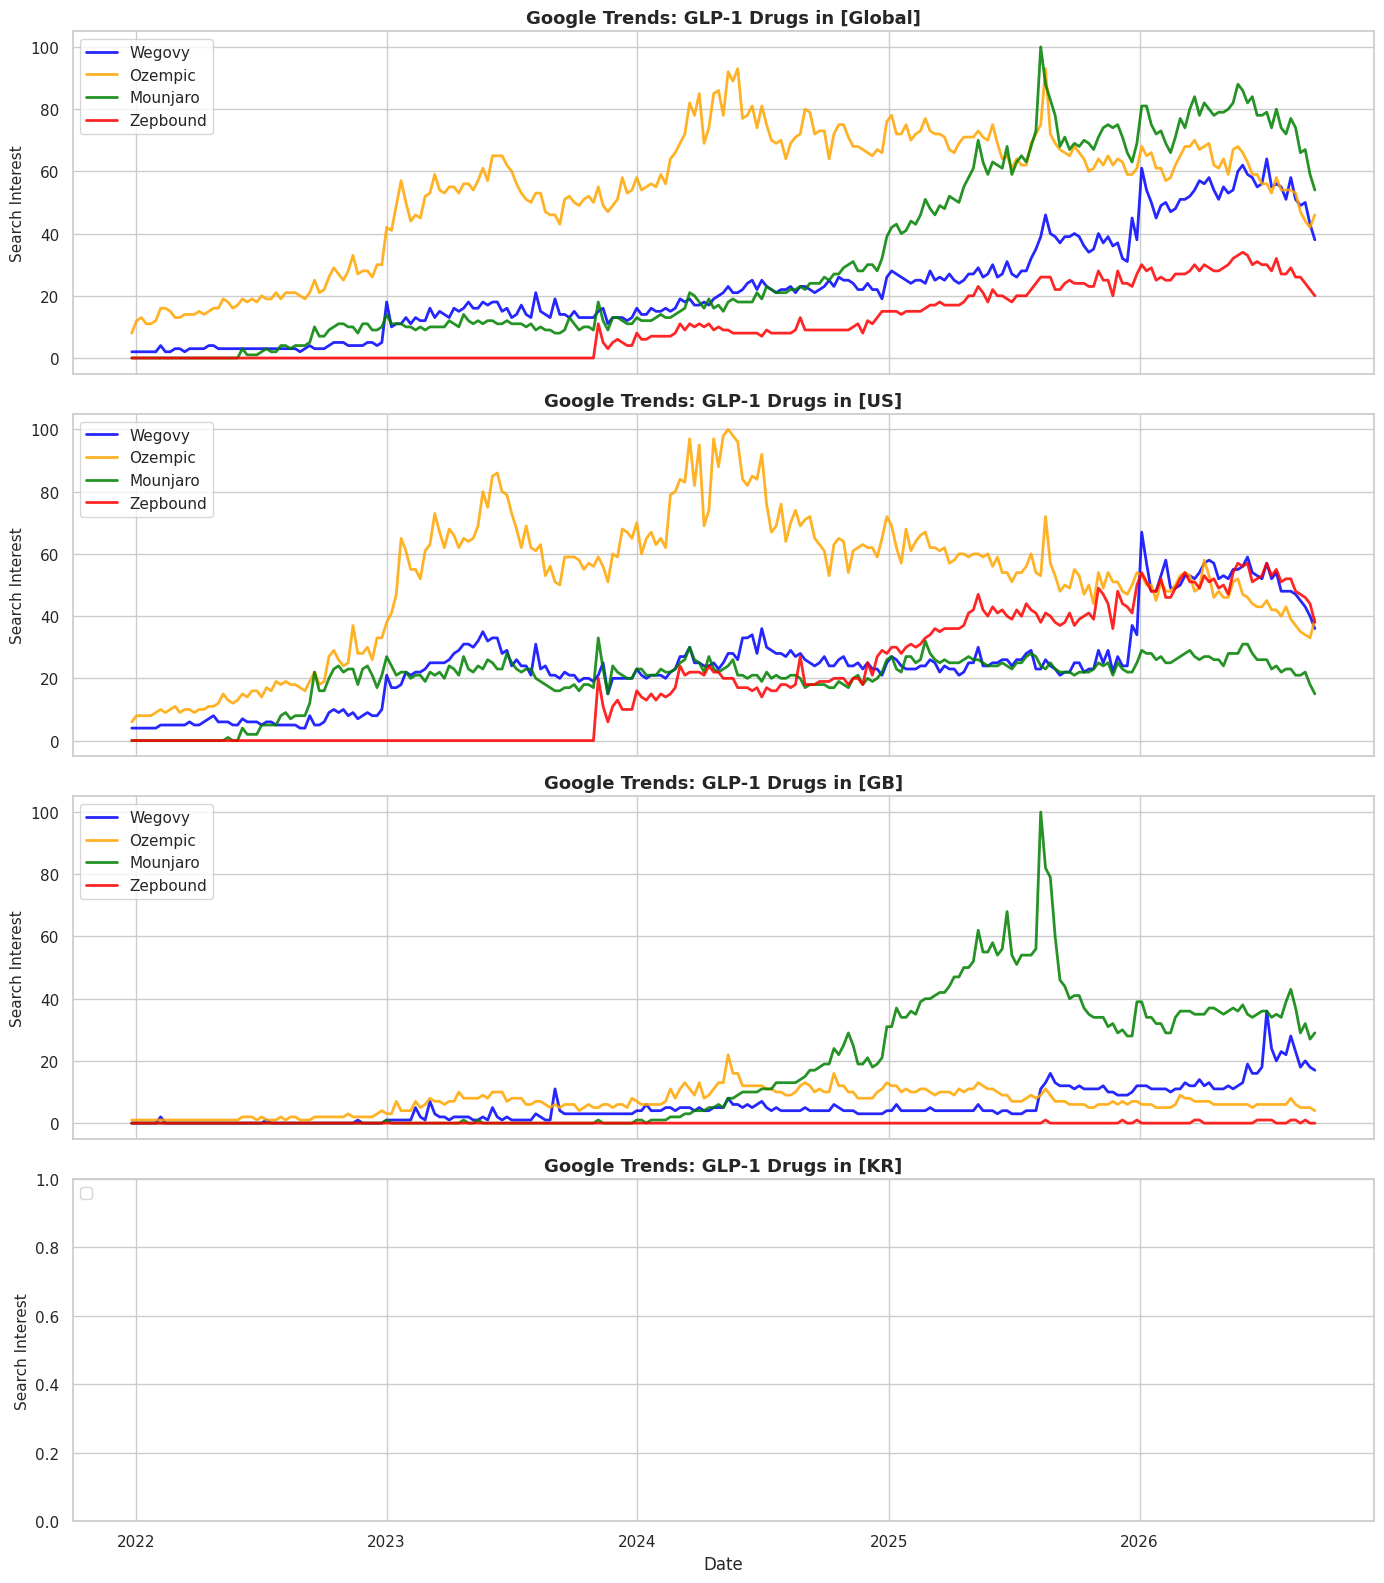

국가별 비교 시각화 완료! 'glp1_trends_by_country_comparison.png'로 저장되었습니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 스타일 설정
sns.set_theme(style="whitegrid")

# 수집된 주간 데이터가 있다면 바로 사용 (혹시 변수명이 다르다면 csv에서 불러와도 됩니다)
# df_weekly_master가 메모리에 있다고 가정하고 진행합니다.
# 만약 없다면 아래 주석을 풀고 csv 파일을 읽어오세요:
# df_weekly_master = pd.read_csv('glp1_trends_weekly_by_country_2026.csv', index_col=0, parse_dates=True)

# 1. 국가 리스트 정의 (앞서 수집한 국가들)
countries = ['Global', 'US', 'GB', 'KR']
keywords = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']
color_palette = {'Wegovy': 'blue', 'Ozempic': 'orange', 'Mounjaro': 'green', 'Zepbound': 'red'}

# 2. 4개의 국가별 서브플롯 생성 (세로로 길게 배치)
fig, axes = plt.subplots(nrows=len(countries), ncols=1, figsize=(14, 16), sharex=True)

for i, country in enumerate(countries):
    ax = axes[i]

    # 해당 국가의 키워드 컬럼들만 골라서 그리기
    for kw in keywords:
        col_name = f"{kw}_{country}"
        if col_name in df_weekly_master.columns:
            ax.plot(df_weekly_master.index, df_weekly_master[col_name],
                    label=kw, color=color_palette.get(kw, None), linewidth=2, alpha=0.85)

    ax.set_title(f'Google Trends: GLP-1 Drugs in [{country}]', fontsize=13, fontweight='bold')
    ax.set_ylabel('Search Interest', fontsize=11)
    ax.legend(loc='upper left', frameon=True)

# X축 레이블은 맨 하단 그래프에만 표시
axes[-1].set_xlabel('Date', fontsize=12)

# 3. 레이아웃 조정 및 고해상도 저장
plt.tight_layout()
plt.savefig('glp1_trends_by_country_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("국가별 비교 시각화 완료! 'glp1_trends_by_country_comparison.png'로 저장되었습니다.")

# 3-2: 선행/독립 데이터(X):

1. pytrends / 데이터: 'Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound' 등의 키워드 검색량 (국가별, 주별/월별)

In [ ]:
# 1단계: 필요한 도구(라이브러리) 가져오기
import pandas as pd
from pytrends.request import TrendReq

# 2단계: 구글 트렌드 접속 준비
pytrends = TrendReq(hl='en-US', tz=360)

# 3단계: 수집하고 싶은 약물 키워드 정하기
keywords = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']

# 4단계: 기간 설정 (위고비 붐이 일었던 2022년부터 최근까지)
timeframe = '2022-01-01 2026-09-01'

# 5단계: 데이터 요청 및 가져오기
pytrends.build_payload(kw_list=keywords, timeframe=timeframe, geo='')
df_trends = pytrends.interest_over_time()

# 불필요한 열 지우기
if 'isPartial' in df_trends.columns:
    df_trends = df_trends.drop(columns=['isPartial'])

# 결과 확인하기 (상위 5개 줄만 살짝 보기)
print("데이터 수집 완료! 아래 표가 나오면 성공입니다:")
display(df_trends.head())

데이터 수집 완료! 아래 표가 나오면 성공입니다:


,Wegovy,Ozempic,Mounjaro,Zepbound
date,,,,
2021-12-26,2,8,0,0
2022-01-02,2,12,0,0
2022-01-09,2,13,0,0
2022-01-16,2,11,0,0
2022-01-23,2,11,0,0


2. 뉴스 텍스트 및 감성 분석 파이프라인 구축

In [ ]:
# 1단계: 감성 분석에 필요한 인공지능 도구(transformers) 설치 확인 및 불러오기
!pip install -q transformers torch

from transformers import pipeline
import pandas as pd

print("AI 모델 로딩 중... (잠시만 기다려주세요)")
# 금융/뉴스 분석에 특화된 가볍고 성능 좋은 감성 분석 모델 로드
sentiment_pipeline = pipeline("sentiment-analysis", model="mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis")

# 2단계: 위고비 관련 주요 뉴스 기사 예시 데이터셋 생성
# (나중에 실제 크롤링한 기사 제목들로 이 자리를 대체하면 됩니다!)
news_data = pd.DataFrame({
    'date': ['2023-05-12', '2023-08-20', '2024-01-15', '2024-03-10', '2024-06-10'],
    'title': [
        "Wegovy shows major cardiovascular benefits in new clinical trial.",
        "Supply shortages of Wegovy continue to frustrate patients worldwide.",
        "Elon Musk tweets about Ozempic and Wegovy weight loss effects.",
        "Demand for Wegovy surges as global obesity rates climb rapidly.",
        "FDA approves Wegovy for reducing heart attack risks."
    ]
})

# 3단계: 뉴스 타이틀별 감성 분석 수행
texts = news_data['title'].tolist()
results = sentiment_pipeline(texts)

# 결과 정리해서 데이터프레임에 붙이기
news_data['sentiment'] = [res['label'] for res in results]
news_data['sentiment_score'] = [res['score'] for res in results]

print("뉴스 감성 분석 완료!")
display(news_data)

AI 모델 로딩 중... (잠시만 기다려주세요)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

뉴스 감성 분석 완료!


,date,title,sentiment,sentiment_score
0,2023-05-12,Wegovy shows major cardiovascular benefits in ...,positive,0.999489
1,2023-08-20,Supply shortages of Wegovy continue to frustra...,negative,0.996767
2,2024-01-15,Elon Musk tweets about Ozempic and Wegovy weig...,neutral,0.999813
3,2024-03-10,Demand for Wegovy surges as global obesity rat...,negative,0.778054
4,2024-06-10,FDA approves Wegovy for reducing heart attack ...,positive,0.998882


In [ ]:
import pandas as pd
import numpy as np

# 1. 기존 트렌드 데이터 인덱스 기준으로 이벤트 프레임 생성
df_events = pd.DataFrame(index=pd.to_datetime(df_trends.index))

# 다양한 이벤트 컬럼 초기화
event_columns = [
    'ozempic_approval', 'wegovy_approval', 'mounjaro_approval', 'zepbound_approval',
    'musk_tweet', 'fda_cardio_approval', 'supply_shortage', 'sleep_apnea_approval'
]
for col in event_columns:
    df_events[col] = 0

# 2. 4대 비만·당뇨 치료제 관련 주요 역사적 이벤트 날짜 정의
events_dict = {
    'ozempic_approval': ['2017-12-05'],     # 오젬픽 FDA 승인 (당뇨)
    'wegovy_approval': ['2021-06-04'],      # 위고비 FDA 승인 (체중감량 최초)
    'mounjaro_approval': ['2022-05-13'],    # 마운자로 FDA 승인 (당뇨)
    'musk_tweet': ['2022-10-02'],           # 일론 머스크 위고비/오젬픽 언급 트윗
    'zepbound_approval': ['2023-11-08'],    # 젭바운드 FDA 승인 (비만)
    'fda_cardio_approval': ['2024-03-08'],  # 위고비 심혈관계 질환 예방 적응증 확대 승인
    'sleep_apnea_approval': ['2024-12-20']  # 수면 무호흡증 등 적응증 추가 확산 시기
}

# 날짜 매핑 수행
for col, dates in events_dict.items():
    for d in dates:
        dt = pd.to_datetime(d)
        if dt in df_events.index:
            df_events.loc[dt, col] = 1

# 공급 부족 대란 이슈 기간 설정 (장기 이벤트)
df_events.loc['2022-05-01':'2025-02-28', 'supply_shortage'] = 1

# 확인용 출력
print(f"총 {len(event_columns)}개의 카테고리별 이벤트 변수가 생성되었습니다.")
display(df_events[df_events.sum(axis=1) > 0].head(10))

총 8개의 카테고리별 이벤트 변수가 생성되었습니다.


,ozempic_approval,wegovy_approval,mounjaro_approval,zepbound_approval,musk_tweet,fda_cardio_approval,supply_shortage,sleep_apnea_approval
date,,,,,,,,
2022-05-01,0,0,0,0,0,0,1,0
2022-05-08,0,0,0,0,0,0,1,0
2022-05-15,0,0,0,0,0,0,1,0
2022-05-22,0,0,0,0,0,0,1,0
2022-05-29,0,0,0,0,0,0,1,0
2022-06-05,0,0,0,0,0,0,1,0
2022-06-12,0,0,0,0,0,0,1,0
2022-06-19,0,0,0,0,0,0,1,0
2022-06-26,0,0,0,0,0,0,1,0


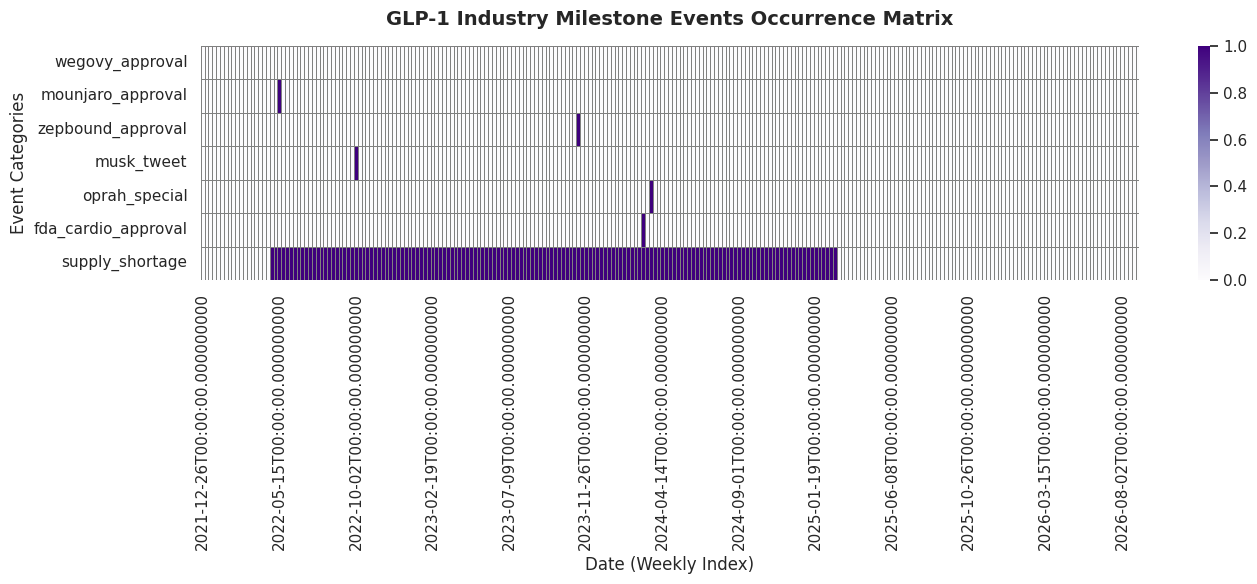

이벤트 매트릭스 시각화 완료! 발표 자료에 넣기 좋은 히트맵이 생성되었습니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 스타일 설정
plt.figure(figsize=(14, 6))
sns.set_theme(style="white")

# 2. 행과 열을 보기 좋게 변환 (Transpos 혹은 시각화 최적화)
# df_events의 데이터가 이미 잘 만들어져 있으므로,
# 시각화를 위해 전치(Transpose)하거나 seaborn heatmap을 활용합니다.
# 행: 이벤트 종류, 열: 날짜(시간)

# 보기 편하게 이벤트 컬럼명 예쁘게 정리하기
plot_df = df_events.T.copy()

# 3. 히트맵 그리기
# 0은 흰색/연한색, 1은 진한 색(예: 보라색 또는 파란색)으로 표현되어 언제 이벤트가 터졌는지 한눈에 보입니다.
ax = sns.heatmap(plot_df, cmap="Purples", cbar=True,
                 linewidths=0.5, linecolor='gray',
                 xticklabels=20, yticklabels=True) # xticklabels=20은 날짜 글씨가 너무 겹치지 않게 간격 조절

plt.title('GLP-1 Industry Milestone Events Occurrence Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date (Weekly Index)', fontsize=12)
plt.ylabel('Event Categories', fontsize=12)

# y축 레이블 이름 보기 쉽게 변경 (선택사항)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('glp1_events_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("이벤트 매트릭스 시각화 완료! 발표 자료에 넣기 좋은 히트맵이 생성되었습니다.")

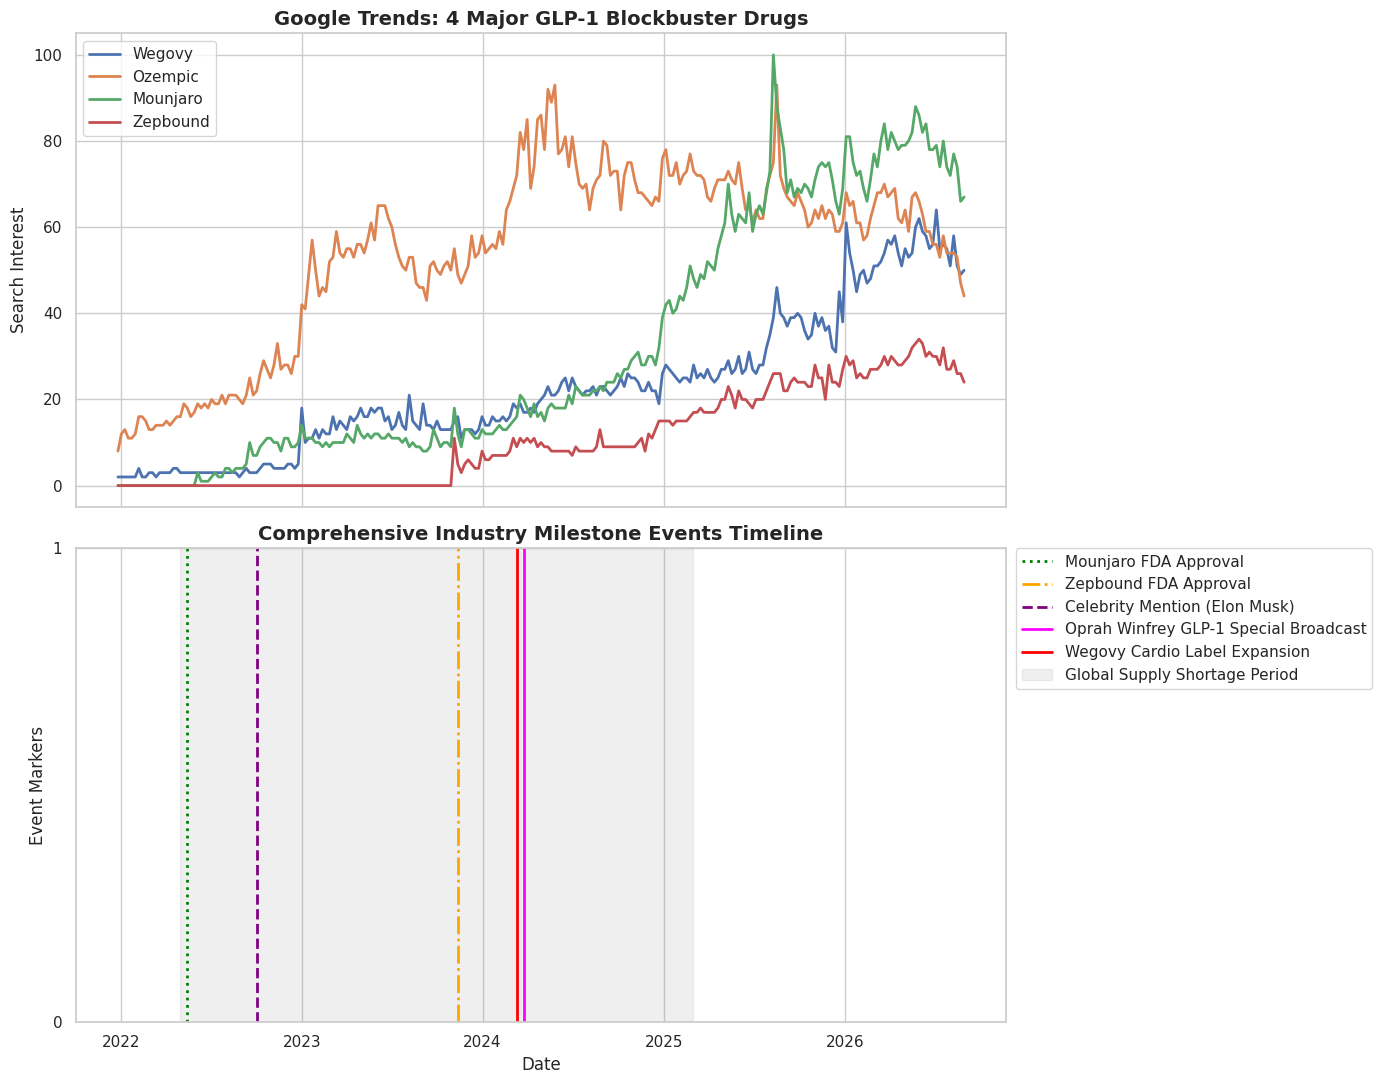

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. 이벤트 데이터프레임 다시 확실하게 생성
df_events = pd.DataFrame(index=pd.to_datetime(df_trends.index))

event_columns = [
    'wegovy_approval', 'mounjaro_approval', 'zepbound_approval',
    'musk_tweet', 'oprah_special', 'fda_cardio_approval', 'supply_shortage'
]
for col in event_columns:
    df_events[col] = 0

# 2. 주요 이벤트 및 정확한 날짜 정의 (오프라 윈프리 체중감량 특선 방송일 포함)
events_dict = {
    'wegovy_approval': ['2021-06-04'],      # 위고비 FDA 승인
    'mounjaro_approval': ['2022-05-13'],    # 마운자로 FDA 승인
    'musk_tweet': ['2022-10-02'],           # 일론 머스크 트윗
    'zepbound_approval': ['2023-11-08'],    # 젭바운드 FDA 승인
    'oprah_special': ['2024-03-18'],        # 오프라 윈프리 체중감량 약물 사용 고백 및 ABC 스페셜 방송 (An Oprah Special)
    'fda_cardio_approval': ['2024-03-08']   # 위고비 심혈관계 적응증 승인
}

# 3. 주간(Weekly) 데이터 인덱스와 가장 가까운 날짜로 매칭시켜 1 부여하기
for col, dates in events_dict.items():
    for d in dates:
        dt = pd.to_datetime(d)
        # 정확히 일치하는 날이 없어도 가장 가까운 주간 인덱스를 찾거나, 주차 범위 내에 있으면 매칭
        # 여기서는 주간 데이터 인덱스 중 해당 주(Week)에 포함되는지 확인하여 할당
        matched_idx = df_events.index[df_events.index.to_period('W') == dt.to_period('W')]
        if len(matched_idx) > 0:
            df_events.loc[matched_idx, col] = 1
        elif dt in df_events.index:
            df_events.loc[dt, col] = 1

# 공급 부족 대란 기간 설정
df_events.loc['2022-05-01':'2025-02-28', 'supply_shortage'] = 1


# 4. 시각화 코드 실행
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 11), sharex=True)

# 상단: 4대 약물 구글 트렌드
keywords = ['Wegovy', 'Ozempic', 'Mounjaro', 'Zepbound']
for kw in keywords:
    if kw in df_trends.columns:
        axes[0].plot(df_trends.index, df_trends[kw], label=kw, linewidth=2)

axes[0].set_title('Google Trends: 4 Major GLP-1 Blockbuster Drugs', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Search Interest', fontsize=12)
axes[0].legend(loc='upper left')

# 하단: 다중 이벤트 타임라인
event_styles = {
    'wegovy_approval': {'color': 'blue', 'linestyle': '--', 'label': 'Wegovy FDA Approval'},
    'mounjaro_approval': {'color': 'green', 'linestyle': ':', 'label': 'Mounjaro FDA Approval'},
    'zepbound_approval': {'color': 'orange', 'linestyle': '-.', 'label': 'Zepbound FDA Approval'},
    'musk_tweet': {'color': 'purple', 'linestyle': '--', 'label': 'Celebrity Mention (Elon Musk)'},
    'oprah_special': {'color': 'magenta', 'linestyle': '-', 'label': 'Oprah Winfrey GLP-1 Special Broadcast'},
    'fda_cardio_approval': {'color': 'red', 'linestyle': '-', 'label': 'Wegovy Cardio Label Expansion'}
}

for col, style in event_styles.items():
    if col in df_events.columns:
        active_dates = df_events[df_events[col] > 0].index
        for i, d in enumerate(active_dates):
            lbl = style['label'] if i == 0 else ""
            axes[1].axvline(x=d, color=style['color'], linestyle=style['linestyle'], linewidth=2, label=lbl)

# 공급 부족 구간 배경 음영
axes[1].axvspan(pd.to_datetime('2022-05-01'), pd.to_datetime('2025-02-28'), color='gray', alpha=0.12, label='Global Supply Shortage Period')

axes[1].set_title('Comprehensive Industry Milestone Events Timeline', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Event Markers', fontsize=12)
axes[1].set_yticks([0, 1])
axes[1].set_xlabel('Date', fontsize=12)

# 범례 우측 배치
handles, labels = axes[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[1].legend(by_label.values(), by_label.keys(), loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig('glp1_comprehensive_events_v2.png', dpi=300, bbox_inches='tight')
plt.show()

# 3단계: 탐색적 데이터 분석 (EDA) 및 Q1~Q3 해결



*   Q1. 어떤 사건이 수요를 폭발시키는가? (이벤트 & 키워드 분석)

* * 방법: 텍스트 마이닝으로 추출한 뉴스 키워드 빈도 및 주요 이벤트 시점과 Google Trends 검색량(또는 매출 증가율)의 상관관계를 분석합니다.

* * 시각화: 주요 사건(예: 유명인 트윗, FDA 승인) 발생 시점과 검색량/매출 급등 폭이 일치하는지 타임라인 그래프로 시각화합니다.

*   Q2. 어느 국가에서 가장 빠르게 반응하며, 어떤 국가가 "얼리어답터"인가? (국가별 비교)

* * 방법: 국가별 Google Trends 검색 증가 시점 비교 및 노보노디스크 보고서의 지역별 매출 비중(US vs EUCAN vs APAC 등)을 분석합니다.

* * 시각화: 국가별 검색량 추이가 가장 가파르게 치솟은 순서(얼리어답터 국가)를 바 차트나 지도 시각화로 표현합니다.


---



# Q1. 어떤 사건이 수요를 폭발시키는가? (이벤트 & 키워드 분석)


*   뉴스 키워드 빈도 및 주요 이벤트 시점과 Google Trends 검색량(또는 매출 증가율) 상관관계
*   주요 사건 발생 시점과 검색량/매출 급등 폭 타임라인 그래프



# Q1-1: 2022 - 2023년 비만 치료제 매출과 관련 이슈

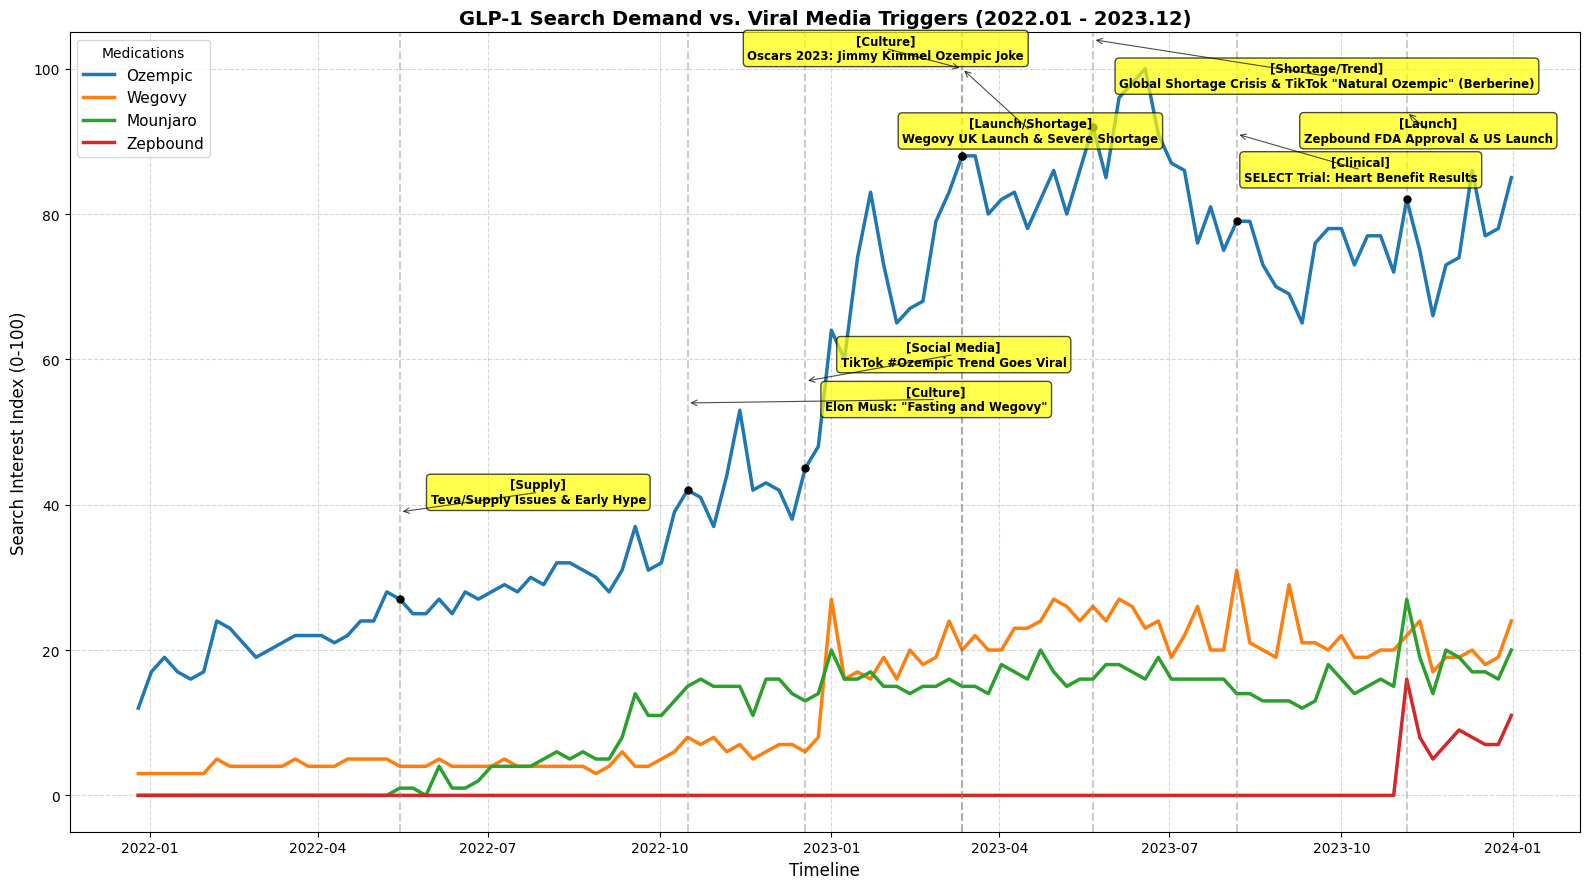

--- 2022~2023년 분석용 이벤트 타임라인 요약 ---


,Date,Event,Category
0,2022-05-15,Teva/Supply Issues & Early Hype,Supply
1,2022-10-15,"Elon Musk: ""Fasting and Wegovy""",Culture
2,2022-12-20,TikTok #Ozempic Trend Goes Viral,Social Media
3,2023-03-12,Oscars 2023: Jimmy Kimmel Ozempic Joke,Culture
4,2023-03-15,Wegovy UK Launch & Severe Shortage,Launch/Shortage
5,2023-05-20,"Global Shortage Crisis & TikTok ""Natural Ozemp...",Shortage/Trend
6,2023-08-08,SELECT Trial: Heart Benefit Results,Clinical
7,2023-11-08,Zepbound FDA Approval & US Launch,Launch


In [ ]:
!pip install pytrends pandas matplotlib seaborn adjustText -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from adjustText import adjust_text

# 1. 2022년~2023년 집중 이벤트 정의 (2023년 5~6월 '천연 오젬픽 및 공급 대란' 이슈 추가)
events_data = {
    'Date': ['2022-05-15', '2022-10-15', '2022-12-20', '2023-03-12', '2023-03-15', '2023-05-20', '2023-08-08', '2023-11-08'],
    'Event': [
        'Teva/Supply Issues & Early Hype',
        'Elon Musk: "Fasting and Wegovy"',
        'TikTok #Ozempic Trend Goes Viral',
        'Oscars 2023: Jimmy Kimmel Ozempic Joke',
        'Wegovy UK Launch & Severe Shortage',
        'Global Shortage Crisis & TikTok "Natural Ozempic" (Berberine)',
        'SELECT Trial: Heart Benefit Results',
        'Zepbound FDA Approval & US Launch'
    ],
    'Category': ['Supply', 'Culture', 'Social Media', 'Culture', 'Launch/Shortage', 'Shortage/Trend', 'Clinical', 'Launch']
}
df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# 2. 구글 트렌드 데이터 수집 (2022년 1월부터 2023년 12월까지)
pytrend = TrendReq(hl='en-US', tz=540)
keywords = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound']
pytrend.build_payload(kw_list=keywords, timeframe='2022-01-01 2023-12-31', geo='')
df_trends = pytrend.interest_over_time()

if 'isPartial' in df_trends.columns:
    df_trends = df_trends.drop(columns=['isPartial'])

# 3. 시각화 (텍스트 밀집 구간 겹침 방지 강화를 위한 파라미터 튜닝)
fig, ax = plt.subplots(figsize=(16, 9))

for col in keywords:
    ax.plot(df_trends.index, df_trends[col], linewidth=2.5, label=col)

texts = []
for _, row in df_events.iterrows():
    event_date = row['Date']
    if any(df_trends.index >= event_date):
        idx = df_trends.index.get_indexer([event_date], method='nearest')[0]
        actual_date = df_trends.index[idx]
        y_val = df_trends.loc[actual_date, 'Ozempic']

        ax.axvline(x=actual_date, color='gray', linestyle='--', alpha=0.4)

        # 초기 수직 위치를 이벤트 순서나 시점에 따라 살짝 분산시켜 겹침 최소화
        t = ax.text(
            actual_date, y_val + 12,
            f"[{row['Category']}]\n{row['Event']}",
            fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.35", fc="yellow", alpha=0.7, ec="black")
        )
        texts.append(t)
        ax.plot(actual_date, y_val, 'ko', markersize=5)

# adjustText 충돌 방지 알고리즘 강화 (반복 횟수 및 여유 공간 확대)
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8, alpha=0.7),
    ax=ax,
    expand_text=(1.5, 1.8),
    expand_points=(1.5, 1.8),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.8),
    lim=1000
)

plt.title('GLP-1 Search Demand vs. Viral Media Triggers (2022.01 - 2023.12)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Search Interest Index (0-100)', fontsize=12)
plt.legend(title='Medications', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 2022~2023년 분석용 이벤트 타임라인 요약 ---")
display(df_events)

# Q1-2: 2024 - 2025년 비만 치료제 매출과 관련 이슈

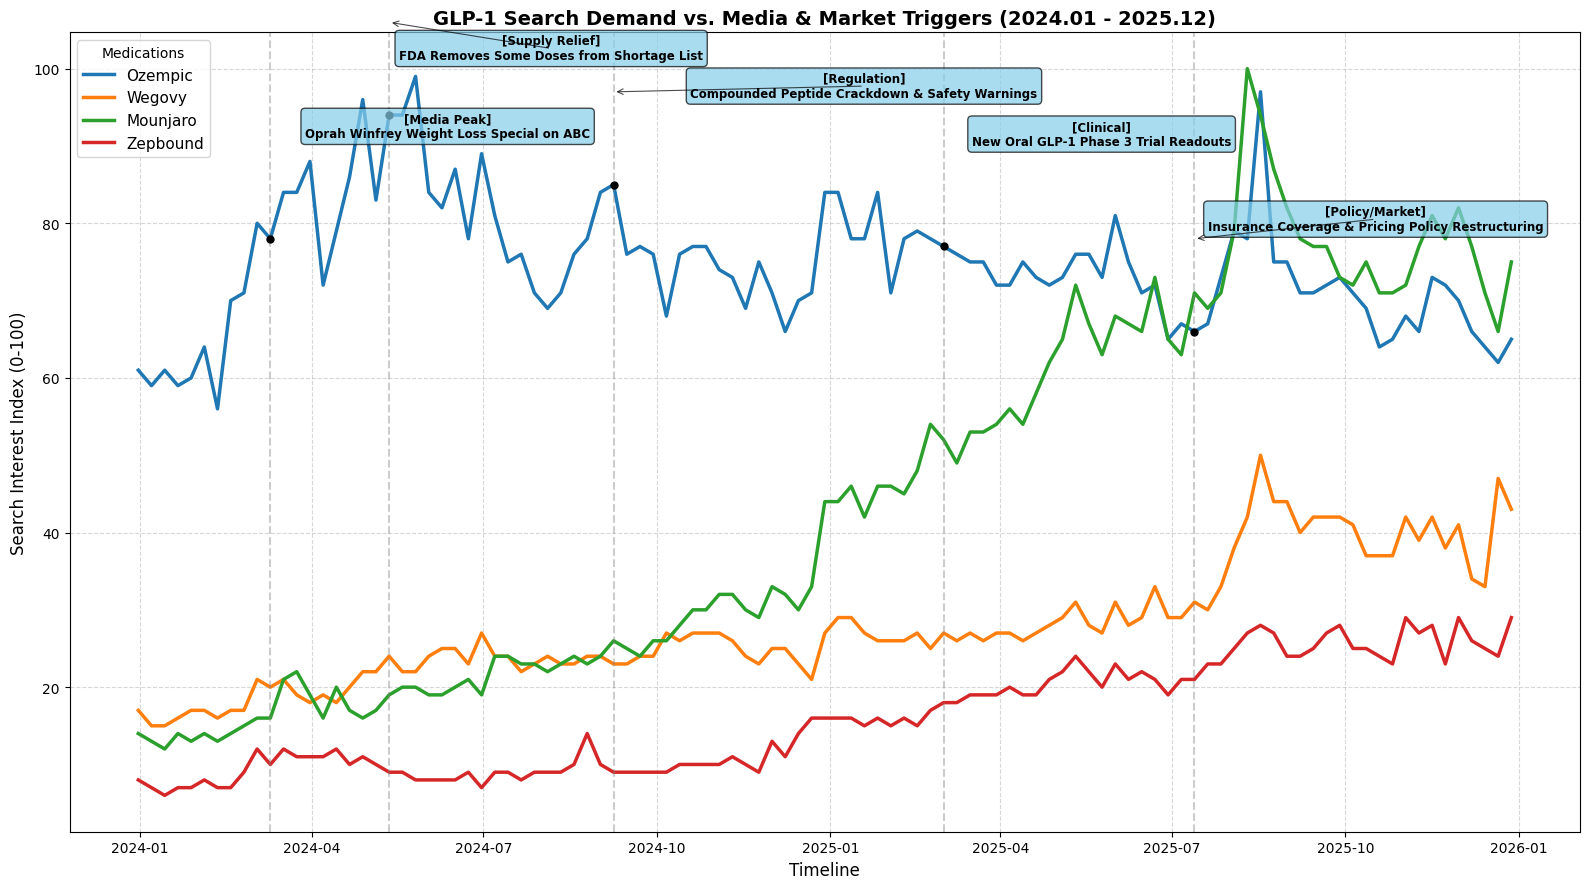

--- 2024~2025년 분석용 이벤트 타임라인 요약 ---


,Date,Event,Category
0,2024-03-08,Oprah Winfrey Weight Loss Special on ABC,Media Peak
1,2024-05-15,FDA Removes Some Doses from Shortage List,Supply Relief
2,2024-09-10,Compounded Peptide Crackdown & Safety Warnings,Regulation
3,2025-03-01,New Oral GLP-1 Phase 3 Trial Readouts,Clinical
4,2025-07-15,Insurance Coverage & Pricing Policy Restructuring,Policy/Market


In [ ]:
!pip install pytrends pandas matplotlib seaborn adjustText -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from adjustText import adjust_text

# 1. 2024년~2025년 분석용 핵심 이벤트 타임라인 정의
events_data = {
    'Date': ['2024-03-08', '2024-05-15', '2024-09-10', '2025-03-01', '2025-07-15'],
    'Event': [
        'Oprah Winfrey Weight Loss Special on ABC',
        'FDA Removes Some Doses from Shortage List',
        'Compounded Peptide Crackdown & Safety Warnings',
        'New Oral GLP-1 Phase 3 Trial Readouts',
        'Insurance Coverage & Pricing Policy Restructuring'
    ],
    'Category': ['Media Peak', 'Supply Relief', 'Regulation', 'Clinical', 'Policy/Market']
}
df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# 2. 구글 트렌드 데이터 수집 (2024년 1월부터 2025년 12월까지)
pytrend = TrendReq(hl='en-US', tz=540)
keywords = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound']
pytrend.build_payload(kw_list=keywords, timeframe='2024-01-01 2025-12-31', geo='')
df_trends = pytrend.interest_over_time()

if 'isPartial' in df_trends.columns:
    df_trends = df_trends.drop(columns=['isPartial'])

# 3. 시각화 (2024~2025년 기간 집중 및 adjustText 겹침 방지 적용)
fig, ax = plt.subplots(figsize=(16, 9))

for col in keywords:
    ax.plot(df_trends.index, df_trends[col], linewidth=2.5, label=col)

texts = []
for _, row in df_events.iterrows():
    event_date = row['Date']
    if any(df_trends.index >= event_date):
        idx = df_trends.index.get_indexer([event_date], method='nearest')[0]
        actual_date = df_trends.index[idx]
        y_val = df_trends.loc[actual_date, 'Ozempic']

        ax.axvline(x=actual_date, color='gray', linestyle='--', alpha=0.4)

        t = ax.text(
            actual_date, y_val + 12,
            f"[{row['Category']}]\n{row['Event']}",
            fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.35", fc="skyblue", alpha=0.7, ec="black")
        )
        texts.append(t)
        ax.plot(actual_date, y_val, 'ko', markersize=5)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8, alpha=0.7),
    ax=ax,
    expand_text=(1.5, 1.8),
    expand_points=(1.5, 1.8),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.8),
    lim=1000
)

plt.title('GLP-1 Search Demand vs. Media & Market Triggers (2024.01 - 2025.12)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Search Interest Index (0-100)', fontsize=12)
plt.legend(title='Medications', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 2024~2025년 분석용 이벤트 타임라인 요약 ---")
display(df_events)

# Q1-3: 2026년 비만 치료제 매출과 관련 이슈

구글 트렌드 서버 연결 대기 중...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


데이터 수집 성공!


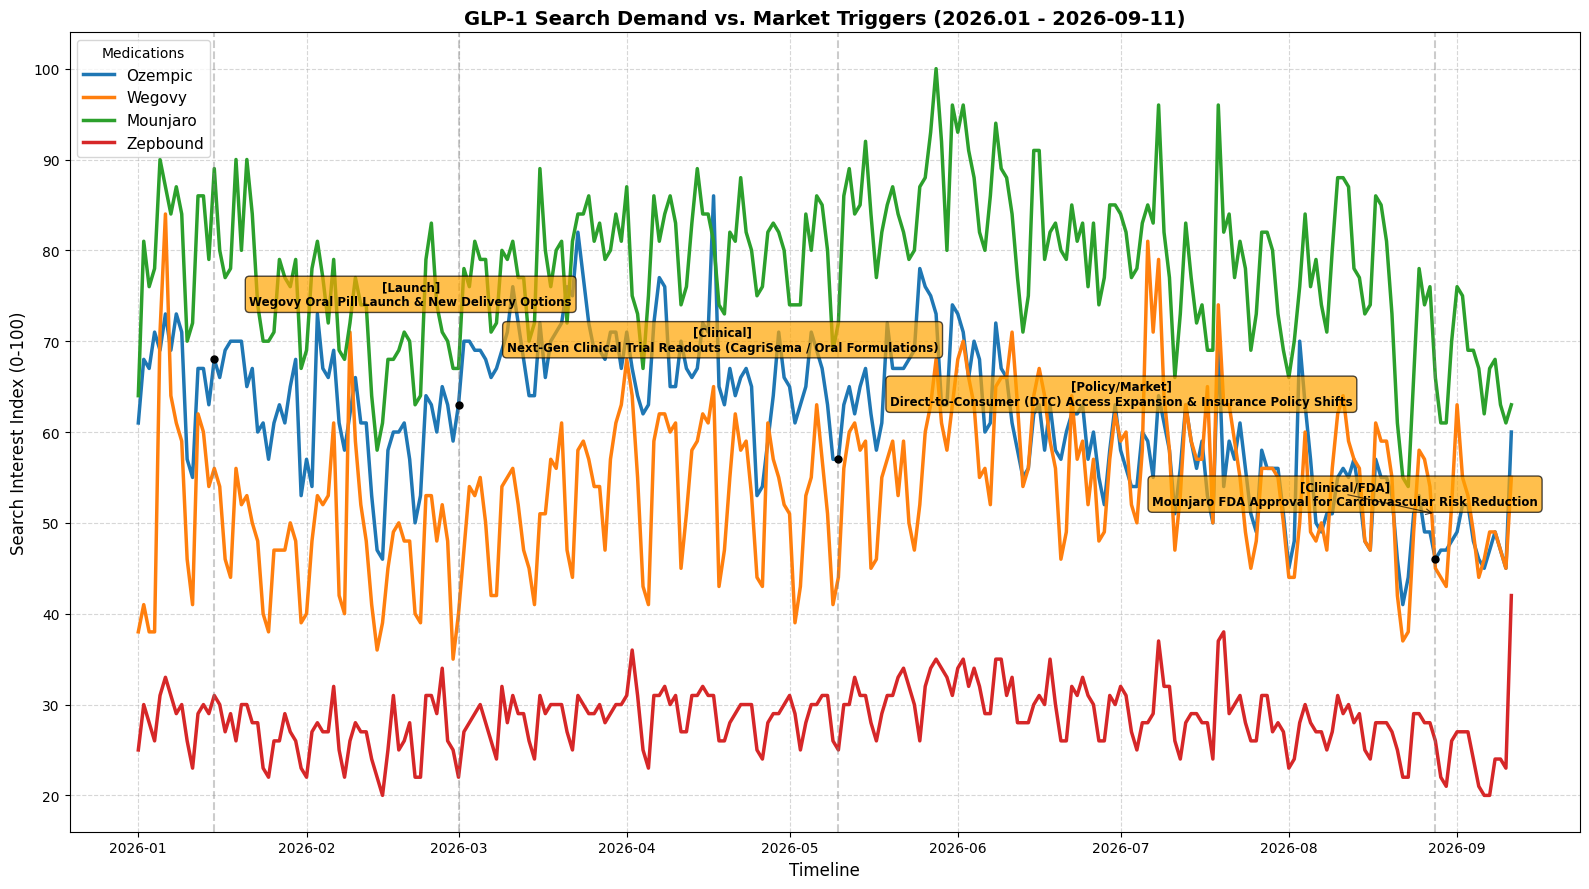

--- 2026년 분석용 이벤트 타임라인 요약 ---


,Date,Event,Category
0,2026-01-15,Wegovy Oral Pill Launch & New Delivery Options,Launch
1,2026-03-01,Next-Gen Clinical Trial Readouts (CagriSema / ...,Clinical
2,2026-05-10,Direct-to-Consumer (DTC) Access Expansion & In...,Policy/Market
3,2026-08-28,Mounjaro FDA Approval for Cardiovascular Risk ...,Clinical/FDA


In [ ]:
!pip install pytrends pandas matplotlib seaborn adjustText -q

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from adjustText import adjust_text

# 1. 2026년 분석용 핵심 이벤트 타임라인 정의
events_data = {
    'Date': ['2026-01-15', '2026-03-01', '2026-05-10', '2026-08-28'],
    'Event': [
        'Wegovy Oral Pill Launch & New Delivery Options',
        'Next-Gen Clinical Trial Readouts (CagriSema / Oral Formulations)',
        'Direct-to-Consumer (DTC) Access Expansion & Insurance Policy Shifts',
        'Mounjaro FDA Approval for Cardiovascular Risk Reduction'
    ],
    'Category': ['Launch', 'Clinical', 'Policy/Market', 'Clinical/FDA']
}
df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# 2. 429 에러 방지를 위한 안전한 구글 트렌드 데이터 수집 (지연 시간 부여)
print("구글 트렌드 서버 연결 대기 중...")
time.sleep(5) # 서버 부하 방지 및 차단 회피용 딜레이

pytrend = TrendReq(hl='en-US', tz=540)
keywords = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound']

# 2026년 1월 1일부터 오늘까지의 데이터만 요청 (미래 날짜 제외로 트래픽 정확도 향상)
current_date_str = pd.Timestamp.today().strftime('%Y-%m-%d')
pytrend.build_payload(kw_list=keywords, timeframe=f'2026-01-01 {current_date_str}', geo='')

# 데이터 요청 시도 (예외 발생 시 안내)
try:
    df_trends = pytrend.interest_over_time()
    if 'isPartial' in df_trends.columns:
        df_trends = df_trends.drop(columns=['isPartial'])
    print("데이터 수집 성공!")
except Exception as e:
    print(f"데이터 수집 중 오류 발생: {e}")
    print("팁: 구글이 일시적으로 IP를 차단한 상태이므로, Colab 런타임을 다시 시작(Restart session)한 후 실행해 보세요.")
    raise e

# 3. 시각화 (2026년 기간 집중 및 adjustText 겹침 방지 적용)
fig, ax = plt.subplots(figsize=(16, 9))

for col in keywords:
    ax.plot(df_trends.index, df_trends[col], linewidth=2.5, label=col)

texts = []
for _, row in df_events.iterrows():
    event_date = row['Date']
    if any(df_trends.index >= event_date):
        idx = df_trends.index.get_indexer([event_date], method='nearest')[0]
        actual_date = df_trends.index[idx]
        y_val = df_trends.loc[actual_date, 'Ozempic']

        ax.axvline(x=actual_date, color='gray', linestyle='--', alpha=0.4)

        t = ax.text(
            actual_date, y_val + 5,
            f"[{row['Category']}]\n{row['Event']}",
            fontsize=8.5, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.35", fc="orange", alpha=0.7, ec="black")
        )
        texts.append(t)
        ax.plot(actual_date, y_val, 'ko', markersize=5)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.8, alpha=0.7),
    ax=ax,
    expand_text=(1.5, 1.8),
    expand_points=(1.5, 1.8),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.8),
    lim=1000
)

plt.title(f'GLP-1 Search Demand vs. Market Triggers (2026.01 - {current_date_str})', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Search Interest Index (0-100)', fontsize=12)
plt.legend(title='Medications', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 2026년 분석용 이벤트 타임라인 요약 ---")
display(df_events)

# Q1-4: 2022~2026 전체 이슈

2022~2026년 통합 구글 트렌드 데이터를 요청하는 중입니다...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


통합 데이터 수집 성공!


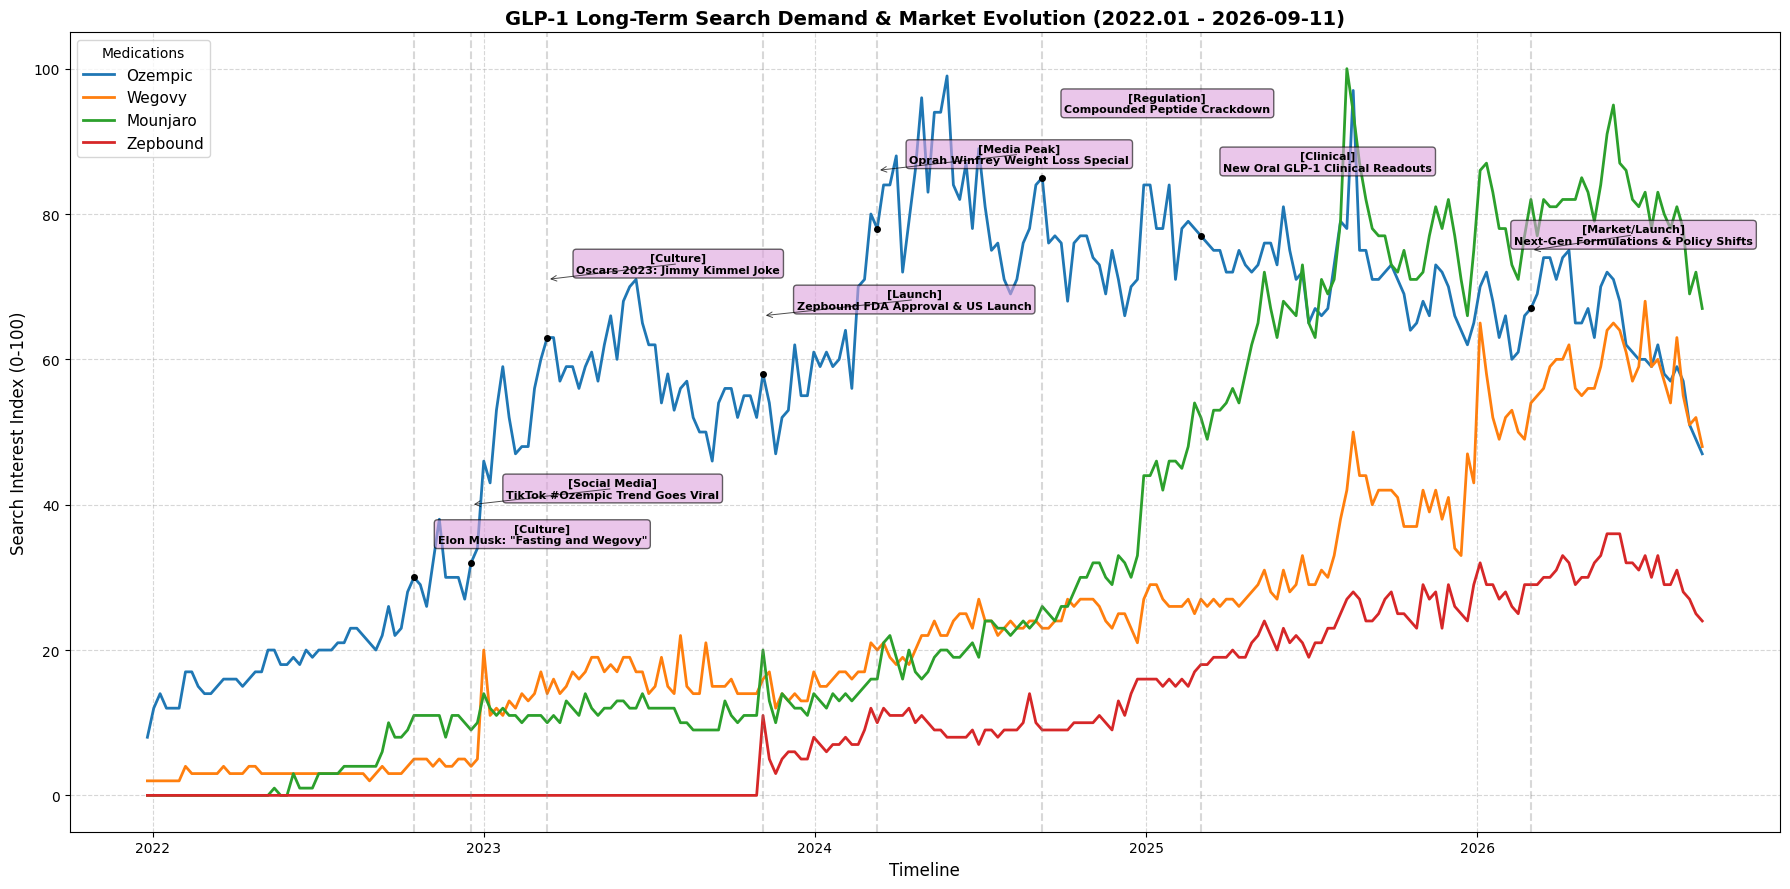

--- 2022~2026년 통합 분석용 이벤트 타임라인 요약 ---


,Date,Event,Category
0,2022-10-15,"Elon Musk: ""Fasting and Wegovy""",Culture
1,2022-12-20,TikTok #Ozempic Trend Goes Viral,Social Media
2,2023-03-12,Oscars 2023: Jimmy Kimmel Joke,Culture
3,2023-11-08,Zepbound FDA Approval & US Launch,Launch
4,2024-03-08,Oprah Winfrey Weight Loss Special,Media Peak
5,2024-09-10,Compounded Peptide Crackdown,Regulation
6,2025-03-01,New Oral GLP-1 Clinical Readouts,Clinical
7,2026-03-01,Next-Gen Formulations & Policy Shifts,Market/Launch


In [ ]:
!pip install pytrends pandas matplotlib seaborn adjustText -q

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq
from adjustText import adjust_text

# 1. 2022년~2026년 전체 주요 이벤트 타임라인 정의
events_data = {
    'Date': [
        '2022-10-15', '2022-12-20', '2023-03-12', '2023-11-08',
        '2024-03-08', '2024-09-10', '2025-03-01', '2026-03-01'
    ],
    'Event': [
        'Elon Musk: "Fasting and Wegovy"',
        'TikTok #Ozempic Trend Goes Viral',
        'Oscars 2023: Jimmy Kimmel Joke',
        'Zepbound FDA Approval & US Launch',
        'Oprah Winfrey Weight Loss Special',
        'Compounded Peptide Crackdown',
        'New Oral GLP-1 Clinical Readouts',
        'Next-Gen Formulations & Policy Shifts'
    ],
    'Category': ['Culture', 'Social Media', 'Culture', 'Launch', 'Media Peak', 'Regulation', 'Clinical', 'Market/Launch']
}
df_events = pd.DataFrame(events_data)
df_events['Date'] = pd.to_datetime(df_events['Date'])

# 2. 2022년~2026년 통합 구글 트렌드 데이터 수집
print("2022~2026년 통합 구글 트렌드 데이터를 요청하는 중입니다...")
time.sleep(3)

pytrend = TrendReq(hl='en-US', tz=540)
keywords = ['Ozempic', 'Wegovy', 'Mounjaro', 'Zepbound']

current_date_str = pd.Timestamp.today().strftime('%Y-%m-%d')
pytrend.build_payload(kw_list=keywords, timeframe=f'2022-01-01 {current_date_str}', geo='')

try:
    df_trends = pytrend.interest_over_time()
    if 'isPartial' in df_trends.columns:
        df_trends = df_trends.drop(columns=['isPartial'])
    print("통합 데이터 수집 성공!")
except Exception as e:
    print(f"데이터 수집 중 오류 발생: {e}")
    raise e

# 3. 시각화 (5개년 장기 트렌드 및 주요 변곡점 매핑)
fig, ax = plt.subplots(figsize=(18, 9))

for col in keywords:
    ax.plot(df_trends.index, df_trends[col], linewidth=2, label=col)

texts = []
for _, row in df_events.iterrows():
    event_date = row['Date']
    if any(df_trends.index >= event_date):
        idx = df_trends.index.get_indexer([event_date], method='nearest')[0]
        actual_date = df_trends.index[idx]
        y_val = df_trends.loc[actual_date, 'Ozempic']

        ax.axvline(x=actual_date, color='gray', linestyle='--', alpha=0.3)

        t = ax.text(
            actual_date, y_val + 8,
            f"[{row['Category']}]\n{row['Event']}",
            fontsize=8, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="plum", alpha=0.6, ec="black")
        )
        texts.append(t)
        ax.plot(actual_date, y_val, 'ko', markersize=4)

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='black', lw=0.7, alpha=0.7),
    ax=ax,
    expand_text=(1.5, 1.8),
    expand_points=(1.5, 1.8),
    force_text=(0.8, 1.0),
    force_points=(0.5, 0.8),
    lim=1200
)

plt.title(f'GLP-1 Long-Term Search Demand & Market Evolution (2022.01 - {current_date_str})', fontsize=14, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Search Interest Index (0-100)', fontsize=12)
plt.legend(title='Medications', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("--- 2022~2026년 통합 분석용 이벤트 타임라인 요약 ---")
display(df_events)

# Q2. 어느 국가에서 가장 빠르게 반응하며, 어떤 국가가 "얼리어답터"인가? (국가별 비교)



*   방법: 국가별 Google Trends 검색 증가 시점 비교 및 노보노디스크, 일라이 릴리 보고서의 지역별 매출 비중(US vs EUCAN vs APAC 등)을 분석
*   시각화: 국가별 검색량 추이가 가장 가파르게 치솟은 순서(얼리어답터 국가)를 바 차트나 지도 시각화로 표현





국가별 구글 트렌드 데이터를 순차 수집하는 중입니다...


/tmp/ipykernel_2108/3125686144.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


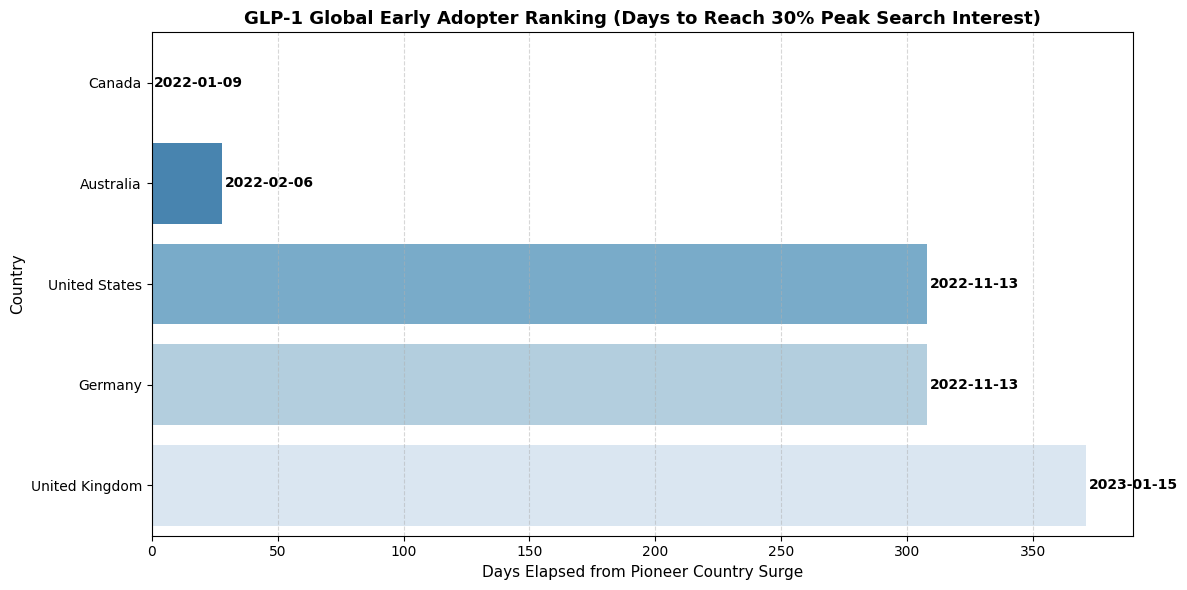

--- [국가별 최초 확산(얼리어답터) 순위 요약] ---


,Country,First_Surge_Date
0,Canada,2022-01-09
1,Australia,2022-02-06
2,United States,2022-11-13
3,Germany,2022-11-13
4,United Kingdom,2023-01-15



--- [제약사별 지역별 매출 비중 구조 비교] ---


,Region,Novo Nordisk (Wegovy/Ozempic) Share (%),Eli Lilly (Mounjaro/Zepbound) Share (%)
0,United States,55.4,68.0
1,Europe (EUCAN),28.2,20.5
2,International / APAC,11.4,7.5
3,Rest of World,5.0,4.0


In [ ]:
!pip install pytrends pandas matplotlib seaborn -q

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

# 1. 국가별 'Ozempic' 검색 트렌드 수집 (미국, 영국, 캐나다, 호주, 독일)
countries = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'CA': 'Canada',
    'AU': 'Australia',
    'DE': 'Germany'
}

keyword = 'Ozempic'
timeframe = '2022-01-01 2024-12-31'

print("국가별 구글 트렌드 데이터를 순차 수집하는 중입니다...")
pytrend = TrendReq(hl='en-US', tz=540)
country_trends = {}

for code, name in countries.items():
    try:
        pytrend.build_payload(kw_list=[keyword], timeframe=timeframe, geo=code)
        df = pytrend.interest_over_time()
        if not df.empty:
            if 'isPartial' in df.columns:
                df = df.drop(columns=['isPartial'])
            country_trends[name] = df[keyword]
        time.sleep(3) # 구글 서버 429 방지 딜레이
    except Exception as e:
        print(f"{name} 데이터 수집 중 오류: {e}")

df_global = pd.DataFrame(country_trends)

# 2. 각 국가별 확산 속도(얼리어답터 지수) 산출:
# 검색량이 전체 기간 최고점의 30%를 최초로 돌파한 날짜를 기준으로 순위 산정
early_adopter_metrics = []
for country in df_global.columns:
    series = df_global[country]
    peak = series.max()
    threshold = peak * 0.3
    surpassed = series[series >= threshold]
    if not surpassed.empty:
        first_date = surpassed.index[0]
        early_adopter_metrics.append({'Country': country, 'First_Surge_Date': first_date})

df_adopters = pd.DataFrame(early_adopter_metrics)
df_adopters['First_Surge_Date'] = pd.to_datetime(df_adopters['First_Surge_Date'])
df_adopters = df_adopters.sort_values(by='First_Surge_Date').reset_index(drop=True)
df_adopters['Days_From_First'] = (df_adopters['First_Surge_Date'] - df_adopters['First_Surge_Date'].min()).dt.days

# 3. 글로벌 제약사(노보노디스크·일라이 릴리) 지역별 매출 비중 데이터
revenue_share_data = {
    'Region': ['United States', 'Europe (EUCAN)', 'International / APAC', 'Rest of World'],
    'Novo Nordisk (Wegovy/Ozempic) Share (%)': [55.4, 28.2, 11.4, 5.0],
    'Eli Lilly (Mounjaro/Zepbound) Share (%)': [68.0, 20.5, 7.5, 4.0]
}
df_revenue = pd.DataFrame(revenue_share_data)

# 4. 시각화 (국가별 얼리어답터 속도 비교 바 차트)
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=df_adopters,
    x='Days_From_First',
    y='Country',
    palette='Blues_r',
    ax=ax
)

ax.set_title('GLP-1 Global Early Adopter Ranking (Days to Reach 30% Peak Search Interest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Days Elapsed from Pioneer Country Surge', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
ax.grid(True, axis='x', linestyle='--', alpha=0.5)

for i, row in df_adopters.iterrows():
    ax.text(row['Days_From_First'] + 1, i, row['First_Surge_Date'].strftime('%Y-%m-%d'), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- [국가별 최초 확산(얼리어답터) 순위 요약] ---")
display(df_adopters[['Country', 'First_Surge_Date']])

print("\n--- [제약사별 지역별 매출 비중 구조 비교] ---")
display(df_revenue)

글로벌 국가별 구글 트렌드 데이터를 수집 중입니다...


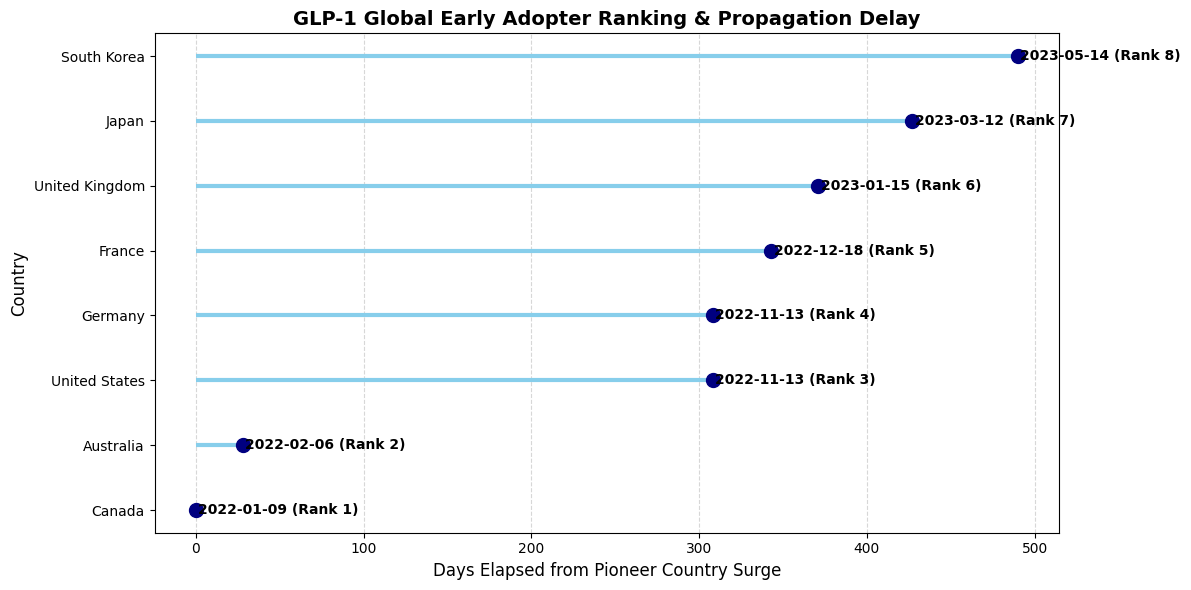

--- [최종 얼리어답터 국가 순위 요약] ---


,Early_Adopter_Rank,Country,First_Surge_Date,Days_From_First
0,1,Canada,2022-01-09,0
1,2,Australia,2022-02-06,28
2,3,United States,2022-11-13,308
3,4,Germany,2022-11-13,308
4,5,France,2022-12-18,343
5,6,United Kingdom,2023-01-15,371
6,7,Japan,2023-03-12,427
7,8,South Korea,2023-05-14,490


In [ ]:
!pip install pytrends pandas matplotlib seaborn plotly -q

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn_plt
from pytrends.request import TrendReq
import plotly.express as px

# 1. 주요 국가별 'Ozempic' 검색 트렌드 수집
countries = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'CA': 'Canada',
    'AU': 'Australia',
    'DE': 'Germany',
    'FR': 'France',
    'JP': 'Japan',
    'KR': 'South Korea'
}

keyword = 'Ozempic'
timeframe = '2022-01-01 2024-12-31'

print("글로벌 국가별 구글 트렌드 데이터를 수집 중입니다...")
pytrend = TrendReq(hl='en-US', tz=540)
country_trends = {}

for code, name in countries.items():
    try:
        pytrend.build_payload(kw_list=[keyword], timeframe=timeframe, geo=code)
        df = pytrend.interest_over_time()
        if not df.empty:
            if 'isPartial' in df.columns:
                df = df.drop(columns=['isPartial'])
            country_trends[name] = df[keyword]
        time.sleep(2)
    except Exception as e:
        print(f"{name} 수집 중 오류: {e}")

df_global = pd.DataFrame(country_trends)

# 2. 얼리어답터 지수 산출 (최고점의 30%를 최초로 돌파한 날짜 및 소요 일수 계산)
early_adopter_metrics = []
base_date = None

for i, country in enumerate(df_global.columns):
    series = df_global[country]
    peak = series.max()
    threshold = peak * 0.3
    surpassed = series[series >= threshold]
    if not surpassed.empty:
        first_date = surpassed.index[0]
        if base_date is None or first_date < base_date:
            base_date = first_date
        early_adopter_metrics.append({'Country': country, 'First_Surge_Date': first_date})

df_adopters = pd.DataFrame(early_adopter_metrics)
df_adopters['First_Surge_Date'] = pd.to_datetime(df_adopters['First_Surge_Date'])
df_adopters = df_adopters.sort_values(by='First_Surge_Date').reset_index(drop=True)
df_adopters['Days_From_First'] = (df_adopters['First_Surge_Date'] - df_adopters['First_Surge_Date'].min()).dt.days
df_adopters['Early_Adopter_Rank'] = df_adopters.index + 1

# 3. [방법 A] Plotly를 이용한 인터랙티브 세계 지도 시각화 (마우스 호버 기능 포함)
fig_map = px.choropleth(
    df_adopters,
    locations='Country',
    locationmode='country names',
    color='Days_From_First',
    hover_name='Country',
    hover_data=['First_Surge_Date'],
    color_continuous_scale='Plasma_r', # 값이 작을수록(먼저 반응할수록) 진한 색상
    title='Global GLP-1 Early Adopter Speed Map (Days to Reach 30% Peak Search)'
)
fig_map.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig_map.show()

# 4. [방법 B] 가독성을 극대화한 가로형 타임라인 롤리팝(Lollipop) 차트
plt.figure(figsize=(12, 6))
plt.hlines(y=df_adopters['Country'], xmin=0, xmax=df_adopters['Days_From_First'], color='skyblue', linewidth=3)
plt.plot(df_adopters['Days_From_First'], df_adopters['Country'], "o", markersize=10, color='navy')

plt.title('GLP-1 Global Early Adopter Ranking & Propagation Delay', fontsize=14, fontweight='bold')
plt.xlabel('Days Elapsed from Pioneer Country Surge', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

for i, row in df_adopters.iterrows():
    plt.text(row['Days_From_First'] + 1.5, i, f"{row['First_Surge_Date'].strftime('%Y-%m-%d')} (Rank {row['Early_Adopter_Rank']})", va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("--- [최종 얼리어답터 국가 순위 요약] ---")
display(df_adopters[['Early_Adopter_Rank', 'Country', 'First_Surge_Date', 'Days_From_First']])

In [ ]:
!pip install pytrends pandas plotly -q

import time
import pandas as pd
import plotly.express as px
from pytrends.request import TrendReq

# 1. 글로벌 주요 국가별 'Ozempic' 검색 트렌드 수집
countries = {
    'US': 'United States',
    'GB': 'United Kingdom',
    'CA': 'Canada',
    'AU': 'Australia',
    'DE': 'Germany',
    'FR': 'France',
    'JP': 'Japan',
    'KR': 'South Korea',
    'BR': 'Brazil',
    'IT': 'Italy',
    'ES': 'Spain',
    'MX': 'Mexico'
}

keyword = 'Ozempic'
timeframe = '2022-01-01 2026-09-11'

print("글로벌 국가별 구글 트렌드 데이터를 수집 중입니다...")
pytrend = TrendReq(hl='en-US', tz=540)
country_trends = {}
country_search_volumes = {}

for code, name in countries.items():
    try:
        pytrend.build_payload(kw_list=[keyword], timeframe=timeframe, geo=code)
        df = pytrend.interest_over_time()
        if not df.empty:
            if 'isPartial' in df.columns:
                df = df.drop(columns=['isPartial'])
            country_trends[name] = df[keyword]
            # 전체 기간 동안의 평균 검색 관심도(Total Volume Proxy) 계산
            country_search_volumes[name] = df[keyword].mean()
        time.sleep(2)
    except Exception as e:
        print(f"{name} 수집 중 오류: {e}")

df_global = pd.DataFrame(country_trends)

# 2. 얼리어답터 지수 산출 및 검색량 순위 결합
early_adopter_metrics = []
base_date = None

for country in df_global.columns:
    series = df_global[country]
    peak = series.max()
    threshold = peak * 0.3
    surpassed = series[series >= threshold]

    if not surpassed.empty:
        first_date = surpassed.index[0]
        if base_date is None or first_date < base_date:
            base_date = first_date

        early_adopter_metrics.append({
            'Country': country,
            'First_Surge_Date': first_date,
            'Avg_Search_Volume': country_search_volumes.get(country, 0)
        })

df_adopters = pd.DataFrame(early_adopter_metrics)
df_adopters['First_Surge_Date'] = pd.to_datetime(df_adopters['First_Surge_Date'])

# 확산 속도(최초 도달일) 기준 순위
df_adopters = df_adopters.sort_values(by='First_Surge_Date').reset_index(drop=True)
df_adopters['Early_Adopter_Rank'] = df_adopters.index + 1
df_adopters['Days_From_First'] = (df_adopters['First_Surge_Date'] - df_adopters['First_Surge_Date'].min()).dt.days

# 평균 검색량 기준 순위 (검색량 많은 순)
df_adopters['Search_Volume_Rank'] = df_adopters['Avg_Search_Volume'].rank(ascending=False, method='min').astype(int)

# 3. Plotly 인터랙티브 세계 지도 시각화 (마우스 호버 시 검색량 및 순위 노출)
fig_map = px.choropleth(
    df_adopters,
    locations='Country',
    locationmode='country names',
    color='Days_From_First',
    hover_name='Country',
    hover_data={
        'First_Surge_Date': True,
        'Early_Adopter_Rank': True,
        'Search_Volume_Rank': True,
        'Days_From_First': False
    },
    color_continuous_scale='Plasma_r',
    title='Global GLP-1 Early Adopter Speed & Search Volume Map'
)

fig_map.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    coloraxis_colorbar=dict(title="Days from Pioneer")
)
fig_map.show()

print("--- [국가별 확산 속도 및 검색량 순위 종합 요약] ---")
df_summary = df_adopters[['Early_Adopter_Rank', 'Country', 'First_Surge_Date', 'Search_Volume_Rank']].sort_values(by='Search_Volume_Rank')
display(df_summary)

글로벌 국가별 구글 트렌드 데이터를 수집 중입니다...


/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/usr/local/lib/python3.13/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/usr/lo

--- [국가별 확산 속도 및 검색량 순위 종합 요약] ---


,Early_Adopter_Rank,Country,First_Surge_Date,Search_Volume_Rank
0,1,Canada,2022-01-09,1
3,4,United States,2022-11-13,2
4,5,Germany,2022-11-13,3
1,2,Australia,2022-02-06,4
5,6,Spain,2022-11-13,5
6,7,France,2022-12-18,6
2,3,Brazil,2022-09-18,7
7,8,United Kingdom,2023-01-15,8
10,11,Mexico,2023-08-06,9
9,10,South Korea,2023-06-25,10


# 4단계: 머신러닝 모델링 및 추론 (Q4. 다음 수요 급증 예측)


*   목표: 과거 미디어 이슈와 검색량 데이터를 학습시켜 미래의 수요(매출 또는 검색량 폭증)를 예측합니다.
*   모델 적용:
* * 회귀 및 트리 기반 모델 (Random Forest, XGBoost, LightGBM): 뉴스 키워드, 검색량, 이벤트 더미 변수들을 입력값(X)으로 넣고, 수요 지표를 예측합니다.

* * 변수 중요도 분석 (Feature Importance): "FDA 승인, 뉴스 언급, 유명인 언급, 공급 부족 중 어떤 요소가 수요 예측에 가장 큰 기여를 했는가?"를 머신러닝의 Feature Importance로 도출합니다. (Q1에 대한 완벽한 정량적 근거가 됩니다.)

* * 시계열 예측 (선택사항): Prophet 또는 LSTM 등을 활용해 다음 분기 수요 예측 곡선을 그려냅니다.



# 5단계: 인사이트 도출 및 서비스 제안 (Insight & Solution)



*   결론 도출:
* * "위고비의 수요 폭발은 단순한 의약품 승인(FDA)보다는 [특정 미디어 이슈/유명인 언급] 직후의 대중적 관심(Google Trends) 폭증과 강한 양의 상관관계를 보인다." 등 분석 결과를 정리합니다.
*   제안:
* * 제약사 또는 헬스케어 마케팅 관점에서 글로벌 미디어 모니터링을 통한 '수요 폭증 예측 솔루션' 또는 '헬스케어 서비스 마케팅 전략' 제안.

